In [14]:
# Imports
import os
import json
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Tuple, Dict, Any, List, Optional
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.gridspec import GridSpec

import os, json, numpy as np, pandas as pd
from glob import glob

# install pyproj if missing -> pip install pyproj
from pyproj import CRS, Transformer

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.9.0+cu128
CUDA available: True


In [65]:
# RUN THIS CELL BEFORE PROCEEDING WITH THE BELOW
# NOTE #
# User needs to have git-lfs, so run:
### !sudo apt install git-lfs
### !git lfs install
# to be able to successfully fetch large download from repo
# Alternatively clone repo in main folder in some other way
# file location: https://github.com/AnetaGancheva/observer_skill_Yu_Kelling_Trueskill_project/blob/main/inputs.7z

import os
import subprocess
import tempfile
from pathlib import Path

import py7zr


def download_and_extract_data():
    """
    Clone the public data repository that holds inputs.7z (tracked via Git LFS),
    download the real 7z file using git-lfs, extract it into ./inputs, and
    clean up the temporary clone.

    Requirements:
        - git
        - git-lfs
        - py7zr
    """

    raw_dir = Path("./")
    raw_dir.mkdir(exist_ok=True)

    repo_url = "https://github.com/AnetaGancheva/birdflow_paper_study.git"

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir_path = Path(tmpdir)
        print(f"Cloning data repo into temporary directory: {tmpdir_path}")

        # 1) Clone repo (shallow clone is fine; we only need current files)
        try:
            subprocess.run(
                ["git", "clone", "--depth", "1", repo_url, str(tmpdir_path)],
                check=True,
            )
        except FileNotFoundError:
            raise RuntimeError(
                "git is not installed or not on PATH. Please install git first."
            )

        # 2) Ensure LFS is available and pull LFS objects (inputs.7z)
        try:
            subprocess.run(
                ["git", "lfs", "install"],
                cwd=tmpdir_path,
                check=True,
            )
            subprocess.run(
                ["git", "lfs", "pull"],
                cwd=tmpdir_path,
                check=True,
            )
        except FileNotFoundError:
            raise RuntimeError(
                "git-lfs is not installed or not on PATH.\n"
                "Install it (e.g. `sudo apt install git-lfs`, then `git lfs install`) "
                "and rerun this function."
            )

        # 3) Locate inputs.7z inside the cloned repo
        src_7z = tmpdir_path / "data_birdflow.7z"
        if not src_7z.exists():
            raise FileNotFoundError(
                f"inputs.7z not found in the cloned repo at {src_7z}.\n"
                "Check that the file exists in the GitHub repository root."
            )

        print(f"Found archive: {src_7z}")

        # 4) Extract directly from the temp repo into ./inputs
        print(f"Extracting {src_7z} into {raw_dir} ...")
        with py7zr.SevenZipFile(src_7z, mode="r") as archive:
            archive.extractall(path=raw_dir)

    # Temporary directory is automatically removed when exiting the context manager
    print("Data successfully downloaded and extracted into.")

download_and_extract_data()

# END
# Alternatively another location for the zipped data file is at:
# https://drive.google.com/drive/folders/11-fshk3U-KT00KD6_J3Ay8DCePBN1IXL?usp=sharing

Cloning data repo into temporary directory: /tmp/tmp7pmf2x4s


Cloning into '/tmp/tmp7pmf2x4s'...


Updated Git hooks.
Git LFS initialized.
Found archive: /tmp/tmp7pmf2x4s/data_birdflow.7z
Extracting /tmp/tmp7pmf2x4s/data_birdflow.7z into . ...
Data successfully downloaded and extracted into.


# BirdFlow: Learning Seasonal Bird Movements from eBird Data - Summary

_______

**Paper information** <br> <br>

**Title:** BirdFlow: Learning seasonal bird movements from eBird data
<br>
**Authors:** Miguel Fuentes, Benjamin M. Van Doren, Daniel Fink, Daniel Sheldon
<br>
**Published:** Methods in Ecology and Evolution, 2023
<br>
**DOI:** https://doi.org/10.1111/2041-210X.14052

______

Summary includes some additional clarifications, so that certain concepts become clearer for the summarizer. These do not alter the paper's main ideas and the presented findings in any way.

______

## Overview

**BirdFlow** is a probabilistic modeling framework that learns to infer individual bird movement behavior from population-level observational data. The key innovation is using relative abundance estimates from the [**eBird Status & Trends**](https://science.ebird.org/en/status-and-trends) project (which tell us where populations of birds are at different times of year, but not how individuals move) to construct detailed movement models that can predict migration routes, timing, connectivity, and future positions of individual birds.

**Core Challenge:** eBird data provides “snapshots” of where bird populations are distributed geographically each week, but it doesn’t track individual birds. How can we infer individual movement patterns from this aggregate information?

**The Paper's Solution:** The framework uses optimization techniques to find a probabilistic model (specifically, a Markov chain) that:
- Produces weekly population distributions matching eBird observations
- Minimizes a proxy for energetic movement costs
- Exhibits realistic behavioral variability (controlled via entropy regularization)

**Validation:** The authors validate BirdFlow models using GPS and satellite tracking data from 11 North American bird species, showing that the models accurately predict bird movements despite being trained only on population-level data.

## Historical context

### The movement ecology challenge

Monitoring animal movement is critical for:
- understanding behaviour, survival, and reproduction
- conservation efforts in the face of climate and landscape change (Fraser et al., 2018)
- scientific research on migration ecology and ecosystem health (Rosenberg et al., 2019)
- disease surveillance and aviation safety

The problem with current approaches:

1. Direct tracking (via wireless tracking devices) are too heavy for most bird species.
2. Radar data provides no information on species identities or individual behaviour.
3. Citizen science projects (e.g. eBird) present only snapshots of species' occurrence, not individual movement tracking data.

The BirdFlow innovation:

- can be applied to any species with abundance estimates on eBird Status and Trends
- models migration trajectories, instead of investigating quantities of interest (e.g. centroid movement, estimated movement speed) like previous studies
- produces probabilitic forecasts
- generates multiple ecological inferences: e.g. routes, timing, connectivity

## Fundamental concepts and Mathematical Framework

### Representing movement as tracks

A **movement track** is a sequence of locations representing an animal's position $x_t$ over time:

$$x_1, x_2, \ldots x_T$$

, where:
- $t \in {1, 2, \ldots, T}$ indexes discrete time intervals (weeks in this paper)
- $x_t$ is the location at week $t$
- $x_t \in \mathcal{X}$, where $\mathcal{X}$ is a finite set of possible locations

The paper makes use of **spatial discretization** - the continuous Earth surface is divided into **grid cells** of $3\text{km} x 3\text{km}$ in the eBird Status and Trends project, while the paper uses **$100-250\text{km}$ resolution$ due to computational constraints. Locations are restricted to terrestrial environments, which allows birds to fly over water, but weekly positions must be over land.

### Probability distribution over tracks

BirdFlow models the **variability** in movement behaviour across a population using probability theory:
- $X_1, X_2, \ldots, X_T$ are random variables representing locations at different times
- A movement model is a joint probability distribution over these variables

Interpretation via an example:
The probability $\Pr(X_1 = 7, X_2 = 14, X_T = 43)$ represents the fraction of the population that follows the specific track $(7, 14, 43)$.

**Key Assumption:** Independence of individuals:
- The model is agnostic to population size
- Different birds can follow different paths
- The distribution captures population-level variability

With $|\mathcal{X}|$ possible locations and $T$ time steps, there are $|\mathcal{X}|^T$ possible tracks. Even with moderate numbers (e.g., 100 locations, 52 weeks), this becomes very large: $100^{52} \approx 10^{104}$ possible tracks. Therefore, the paper makes additional restricting assumptions on the vector $\vec{p} = \vert\mathcal{X}\vert^T$, and decides on a **Markovian model**.

### Marginal distributions

BirdFlow connects the full track distribution to observable quantities (weekly population distributions) through **marginal distributions**.

For any week $t$, the weekly marginal $\mu_t$ is a vector where each entry specifies the probability that a bird is at a particular location:

$$\mu_t(x_t) = \Pr(X_t = x_t)$$

This is computed from the full track distribution by summing over all possible values of the other weeks:

$$\mu_t(x_t) = \sum_{x_1, \ldots, x_{t-1}, x_{t+1}, \ldots, x_T} \Pr(X_1 = x_1, \ldots, X_T = x_T)$$

**Interpretation:** $\mu_t(x_t)$ is the fraction of the population located in cell $x_t$ during week $t$.

The eBird Status & Trends project provides estimates of relative abundance, which after normalization give empirical estimates $\hat{\mu}_t$ of these weekly marginals.

**Pairwise Marginal Distributions:**
For consecutive weeks $t$ and $t+1$, the pairwise marginal $\mu_{t,t+1}$ is a matrix where each entry specifies the probability of being at a pair of locations:

$$\mu_{t,t+1}(x_t, x_{t+1}) = \Pr(X_t = x_t, X_{t+1} = x_{t+1})$$

**Interpretation:** This tells us the fraction of the population that is in cell $x_t$ at week $t$ AND in cell $x_{t+1}$ at week $t+1$, which captures movement between these locations.

We proceed to use:
- $\mu$ to represent the collection of all relevant marginals
- $\hat{\mu}$ to represent the collection of all empirical (eBird-derived) weekly marginals

### The inverse problem

BirdFlow addresses the **inverse problem**:
- forward problem: given a full track distribution, compute marginals (easy)
- inverse problem: given marginals, find a track distribution that produces them (hard)
- many different track distributions can produce the same marginals, but we need one that is ecologically realistic

## The BirdFlow Methodology

### Overview of modelling pipeline

1. Pre-processing: convert eBird relative abundance to weekly population distributions
2. Loss function specification: Define what is a good movement model
3. Model structure selection: Choose the family of models to search over
4. Optimization: Find the best model by minimizing the loss function
5. Validation: Evaluate model quality using GPS tracking data


The relative abundance data from [eBird status and trends](https://science.ebird.org/en/status-and-trends) is situated into ```./data/raw/ebirdst/2023``` in subfolders named after species name abbreviations.

### Data pre-processing

**Input data source** is the eBird Status and Trends project:
- Based on eBird observations
- Covers 600+ species
- Spatial resolution: 3 km × 3 km grid
- Temporal resolution: weekly
- Produces relative abundance estimates (not absolute counts)

This is better than using raw eBird observations because:
- Spatiotemporal completeness: Models fill gaps where observations are sparse
- Bias correction: Accounts for systematic variation in citizen science data:
* Observer expertise differences5
* Effort variation (weekends vs. weekdays)
* Spatial sampling bias (near roads, populated areas)

**Pre-processing Steps:**
1. Download raster data for target species at 27 km resolution
2. Re-projection to **Mollweide equal-area projection** (preserves area relationships)
3. Spatial aggregation to coarser grid (100-250 km):
- Necessary due to GPU memory constraints
- Limit of ~4000 cells for 52-week models
- Trade-off: captures migration-scale movements but not local movements

4. Masking: Restrict to terrestrial environments using coastline shapefiles
- Birds can fly over water
- But weekly positions must be over land

5. Normalization: For each week, divide cell values by total abundance:

$$\hat{\mu}t(x_t) = \frac{\text{eBird abundance}(x_t, t)}{\sum$$}} \text{eBird abundance}(x, t)

**Result:** A set of **“ground truth”** weekly marginals $\hat{\mu}_t$ for $t = 1, \ldots, T$ (typically $T = 52$ weeks).

### Loss function

The loss function $\mathcal{L}$ assigns a numerical score to any proposed movement model, with the convention that lower scores are better. The BirdFlow loss has three components:

$$\mathcal{L} = \mathcal{L}{\text{loc}}(\mu, \hat{\mu}) + \alpha \mathcal{L}(\mu) - \beta H(\mu)$$

where:
- $\mathcal{L}{\text{loc}}$: location loss (match weekly distributions)
- $\mathcal{L}$: movement loss (energetic costs)
- $H(\mu)$: entropy (behavioral variability)
- $\alpha, \beta$: hyperparameters controlling relative importance

#### Location loss $\mathcal{L}{\text{loc}}$

**Mathematical definition:**
$$\mathcal{L}_{\text{loc}}(\mu, \hat{\mu}) = \frac{1}{T\vert\mathcal{X}\vert} \sum_{t=1}^{T} ( \mu_t(x_t) - \hat{\mu}_t (x_t) )^2$$

**Intuitive Explanation:**
- For each week $t$ and each location $x_t$:
- Compute the difference between model probability $\mu_t(x_t)$ and eBird probability $\hat{\mu}_t(x_t)$
- Square this difference (penalizes large errors more)
- Sum over all locations and all weeks
- Divide by $T$ to get average per-week error

**Goal:** Ensure the model’s weekly distributions match eBird observations via minimizing location loss

**Properties:**
- This is the mean squared error between distributions
- $\mathcal{L}{\text{loc}} = 0$ if and only if $\mu_t = \hat{\mu}_t$ for all weeks
- Always non-negative: $\mathcal{L} \geq 0$

#### Movement loss $\mathcal{L}$

**Mathematical definition:**

$$\mathcal{L}_{\text{mov}}(\mu) =  \sum_{t=1}^{T-1} \sum_{x_t \in \mathcal{X}} \sum_{x_{t+1} \in \mathcal{X}} \mu_{t,t+1}(x_t, x_{t+1}) \cdot c(x_t, x_{t+1})$$

where:
- $\mu_{t,t+1}(x_t, x_{t+1})$ = probability of transitioning from $x_t$ to $x_{t+1}$
- $c(x_t, x_{t+1})$ = user-defined energetic cost of that transition

**Intuitive Explanation:**
- For each consecutive pair of weeks and each pair of locations:
- Take the probability of that movement
- Multiply by the cost of that movement
- Sum over all possible movements and all weeks

$\mathcal{L}_{\text{mov}}$ equals the expected total energetic cost incurred by a randomly sampled bird over the year. Minimizing this encourages the model to favor energetically efficient movement patterns.

The authors use a fractional power of distance:
$$c(x_t, x_{t+1}) = (d(x_t, x_{t+1}))^\gamma$$
where:
- $d(x_t, x_{t+1})$ = Euclidean distance between cell centroids
- $\gamma$ = distance exponent hyperparameter ($\gamma < 1$)
- $\gamma<1$ ensures that: cost increases less than proportionally with distance, more consistent with observed bird behavior (Newton, 2008)

Minimizing $\mathcal{L}_{\text{mov}}$ encourages:
- Short-distance movements when birds are moving
- Direct routes between seasonal habitats
- Spatially coherent paths (not random jumps)

#### Entropy regularization

**The Overconfidence Problem:**

Without regularization, optimization finds models where birds follow very “narrow” optimal paths — essentially all birds follow the exact same route. Real populations show more variability.

**Solution:** Add an entropy term that encourages dispersion in the model.

**Shannon Entropy:** The entropy of a probability distribution measures its “spread” or “uncertainty”:
- High entropy: distribution is spread out, outcomes are uncertain
- Low entropy: distribution is concentrated, outcomes are predictable

**Mathematical Definition:**

The entropy regularization term is the negative entropy of the track distribution:

$$J(\mu) = -H(\mu)$$

, where $H(\mu)$ is the Shannon entropy.

**Why Negative?**
- Higher entropy = more dispersion (desired)
- But we’re minimizing the loss function
- So we minimize negative entropy, which maximizes entropy

**Computing Entropy for a Markov Chain:**

For a general distribution over tracks, computing entropy would require summing over all $|\mathcal{X}|^T$ possible tracks—completely infeasible.

**Key Insight:** For a Markov chain, entropy can be expressed in terms of marginal entropies (Wainwright & Jordan, 2008):

$$J(\mu) = \sum_{t=1}^{T} H(\mu_t) - \sum_{t=1}^{T-1} H(\mu_{t,t+1})$$

, where:

$$H(\mu_t) = -\sum_{x_t \in \mathcal{X}} \mu_t(x_t) \log \mu_t(x_t)$$

$$H(\mu_{t,t+1}) = -\sum_{x_t \in \mathcal{X}} \sum_{x_{t+1} \in \mathcal{X}} \mu_{t,t+1}(x_t, x_{t+1}) \log \mu_{t,t+1}(x_t, x_{t+1})$$

**Intuitive Explanation:** “how many bits of information are needed to specify an outcome”:
1. $\sum_{t=1}^{T} H(\mu_t)$: Total bits needed to specify all weekly positions independently
2. $\sum_{t=1}^{T-1} H(\mu_{t,t+1})$: Total bits needed to specify all consecutive position pairs
3. Their difference: The entropy of the full track sequence

The formula works because in a **Markov chain**, specifying all pairwise transitions is equivalent to specifying the full track.

Effect of the Entropy Hyperparameter $\beta$:
- $\beta = 0$: No entropy regularization → over-concentrated paths
- Small $\beta$: Slight dispersion → under-dispersed forecasts
- Optimal $\beta$: Realistic dispersion → well-calibrated forecasts
- Large $\beta$: Too much dispersion → over-dispersed forecasts

Calibration Trade-off:
The paper shows (Figure 4) that there’s a “sweet spot” for $\beta$ where forecasts are well-calibrated — not too concentrated, not too spread out.

#### The complete loss function

Combining all components:
$$\min_{\theta} \mathcal{L}(\mu(\theta)) = \mathcal{L}{\text{loc}}(\mu(\theta), \hat{\mu}) + \alpha \mathcal{L}(\mu(\theta)) - \beta H(\mu(\theta))$$

**Hyperparameters:**
- $\alpha$: Weight on movement loss (the authors use $\alpha \approx 1$ after preliminary experi‐
ments)
- $\beta$: Weight on entropy regularization (species-dependent, requires tuning)
- $\gamma$: Distance exponent in cost function (typically $\gamma < 1$)

**Interpretation:** Find the movement model (parameterized by $\theta$) that best balances:
1. Matching observed weekly distributions (via $\mathcal{L}{\text{loc}}$)
2. Minimizing energetic costs (via $\alpha \mathcal{L}$)}
3. Maintaining realistic variability (via $-\beta H$)

### Markov chains

The loss function depends only on marginals $\mu$ (weekly and pairwise distributions), not the full track distribution. This creates an underdetermined problem: many different track distributions can produce the same marginals and thus achieve the same loss.

**Question:** Among all track distributions with the same marginals, which should we choose?
**Answer:** The one that makes the fewest additional assumptions — the principle of maximum entropy (Jaynes, 1957).

#### Maximum Entropy Principle

Given a set of marginals as constraints, the maximum entropy distribution is a **probabilistic graphical model** whose structure reflects the marginal constraints (Wainwright & Jordan, 2008).

For BirdFlow:
- The loss uses weekly marginals $\mu_t$ and pairwise marginals $\mu_{t,t+1}$
- The maximum entropy distribution with these marginals is a Markov chain
- In a Markov chain, $X_{t+1}$ depends only on $X_t$, not on earlier history

Implication: Restricting to Markov chains

#### Definition

A Markov chain is specified by:
1. Initial distribution:

$$\mu_1(x_1) = \Pr(X_1 = x_1)$ for all $x_1 \in \mathcal{X}$$

- Describes where birds are in week 1

2. Transition probabilities: For each week $t = 1, \ldots, T-1$:
  
$$T_{t,t+1}(x_t, x_{t+1}) = \Pr(X_{t+1} = x_{t+1} | X_t = x_t)$$

- Describes the probability of moving from $x_t$ to $x_{t+1}$


**Key Property:** Given the current location, the future is independent of the past:

$$\Pr(X_{t+1} | X_1, \ldots, X_t) = \Pr(X_{t+1} | X_t)$$

**Computing Marginals from a Markov Chain**

Given initial distribution and transitions, we can compute:

- Weekly marginals:
$$\mu_1 = \text{given}$$

$$\mu_{t+1}(x_{t+1}) = \sum_{x_t \in \mathcal{X}} \mu_t(x_t) \cdot T_{t,t+1}(x_t, x_{t+1})$$

- Pairwise marginals:

$$\mu_{t,t+1}(x_t, x_{t+1}) = \mu_t(x_t) \cdot T_{t,t+1}(x_t, x_{t+1})$$

**Computational Advantage:** Instead of storing $|\mathcal{X}|^T$ probabilities for all possible tracks, we only need:
- $|\mathcal{X}|$ numbers for initial distribution
- $(T-1) \times |\mathcal{X}|^2$ numbers for all transitions
- Total: $|\mathcal{X}| + (T-1)|\mathcal{X}|^2$ parameters

E.g. for $|\mathcal{X}| = 100$, $T = 52$:
- Full distribution: $100^{52} \approx 10^{104}$ numbers (impossible)
- Markov chain: $100 + 51 \times 100^2 = 510,100$ numbers (manageable)

#### Non-homogenous Markov chains


**Time-homogeneous** transition probabilities are the same every week

**Time-inhomogeneous** (BirdFlow) - Different transitions for each week:
- Bird behavior varies seasonally
- Spring migration differs from fall migration10
- Breeding vs. wintering vs. migration periods have different movement patterns
- Allows the model to capture these seasonal differences

### Optimization: Finding the best model

#### Parametrization using Softmax

Re-parameterize using the **softmax function**, which automatically enforces non-negativity of probabilities and that the probabilities sum up to $1$.

**The Softmax Function:**

For any vector $u = (u_1, \ldots, u_n)$ of unconstrained real numbers:

$$\sigma_i(u) = \frac{\exp(u_i)}{\sum_{j=1}^{n} \exp(u_j)}$$


**Markov Chain Parameterization:**

The parameter vector $\theta$ consists of:

$$\theta = (\theta^{(1)}, \theta^{(1,2)}, \theta^{(2,3)}, \ldots, \theta^{(T-1,T)})$$

,where:
- $\theta^{(1)} \in \mathbb{R}^{|\mathcal{X}|}$ = unconstrained vector for initial distribution
- $\theta^{(t,t+1)} \in \mathbb{R}^{|\mathcal{X}| \times |\mathcal{X}|}$ = unconstrained matrix for week-$t$ transitions

Total number of parameters: $N = |\mathcal{X}| + (T-1)|\mathcal{X}|^2$

Transformation to Probabilities:
1. Initial distribution:
$$\mu_1 = \sigma(\theta^{(1)})$$
2. Transition probabilities: For each $t$ and each $x_t$, row $x_t$ of the transition matrix is:

$$T_{t,t+1}(x_t, \cdot) = \sigma(\theta^{(t,t+1)}_{x_t, \cdot})$$

, where we apply softmax to each row independently.

#### Gradient descent

Since the loss function and the mapping $\mu(\theta)$ are both differentiable, we can use **gradient descent**.

After convergence, the resulting Markov chain is:
- A (local) minimizer of the loss function
- Among all models with the same marginals, it has maximum entropy
- Therefore, it’s the maximum-entropy solution to the original problem

## Model validation

To evaluate whether BirdFlow models are accurate, the authors use GPS and satellite tracking data from wild birds:
- MoveBank repository and other sources
- 11 bird species (Table below)
- GPS and satellite tracking devices
- High-precision location estimates
- Summary Table (ref. Table 1. from paper):


|        Species         |                                   Reference                                                | Link to data | Note for summary |
|------------------------|--------------------------------------------------------------------------------------------|--------------|------------------|
| American Woodcock      | Moore et al. (2021a, 2021b).                                                               |    [Link](https://datarepository.movebank.org/entities/datapackage/fca13935-d967-491b-a59a-5cf3de80ed2a)          |                  |
| Black-bellied Plover   | Harrison (2022).                                                                           |    N/A          | Could not find data from the paper - missing from Movebank                 |
| Broad-winged Hawk      | McCabe and Goodrich (2022) and McCabe et al. (2020).                                       |    [Link](https://www.movebank.org/cms/webapp?gwt_fragment=page%3Dstudies%2Cpath%3Dstudy28691134)          |                  |
| Blue-winged Teal       | Ramey et al. (2019).                                                                       |              | Could not find data from the paper - missing from Movebank                  |
| Long-billed Curlew     | Carlisle (2022).                                                                           |     [Link](https://www.movebank.org/cms/webapp?gwt_fragment=page%3Dstudies%2Cpath%3Dstudy42451582)         |                  |
| Osprey                 | Bierregaard (2019), Jensen (2018), Martell and Douglas (2019) and Martell et al. (2001).   |              |                  |
| Swainson's Hawk        | Kochert (1998) and Kochert et al. (2011).                                                  |    [Link](https://www.movebank.org/cms/webapp?gwt_fragment=page=studies,path=study8868155)          |                  |
| Tundra Swan            | Ely et al. (2020).                                                                         |              | Could not find data from the paper - missing from Movebank                  |
| Turkey Vulture         | Bildstein et al. (2014) and Dodge et al. (2014).                                           |              | Could not find data from the paper - missing from Movebank                 |
| Whimbrel               | Tibbitts et al. (2018).                                                                    |              | Could not find data from the paper - missing from Movebank                  |
| Wood Thrush            | Stanley et al. (2021).                                                                     |              | Could not find data from the paper - missing from Movebank                  |


Table 1 notes:
- Wide diversity of migration patterns
- Distances range from c.a. $1,300$ km (Woodcock) to c.a. $10,900$ km (Whimbrel)
- Sufficient data for validation (tens to hundreds of tracks per species)

All of the Movebank data has been downloaded for American Woodcock (amewoo), Broad-winged hawk (brwhaw), and Long-billed curlew (lobcur). I was not able to process the rest of the available datasets, so I will proceed with just these three species.

All of the Movebank data is situated into ```./data/tracks/raw```. Transitions are calculated based on the raw files into ``.csv``'s situated into ```./data/tracks/processed```.


### Average Log-Likelihood (ALL)

**Motivation:** How well does the model predict the observed movements of tracked birds?

**Mathematical Definition Log-Likelihood:**

For an observed track $x = (x_1, \ldots, x_T)$ and model parameters $\theta$:

$$\log p_\theta(x_1, \ldots, x_T) = \log p_\theta(x_1) + \sum_{t=1}^{T-1} \log p_\theta(x_{t+1} | x_t) $$

, where:
- Initial position probability: $\log p_\theta(x_1)$
- Transition probabilities: $\log p_\theta(x_{t+1} | x_t)$ for each movement


However:
- Different species have different numbers of tracks
- Tracks have different lengths
- Hard to compare across species


**Solution:** **Average** Log-Likelihood per Transition

Create a dataset $\mathcal{D}$ of all observed movements (transitions):
- Each movement is a triple $(t, x, x’)$ where:
- $t$ = starting week
- $x$ = location in week $t$
- $x’$ = location in week $t+1$
- Include all consecutive observations from all tracks

**Average Log-Likelihood:**

$$\text{ALL}(\mathcal{D}, \theta) = \frac{1}{\vert \mathcal{D} \vert} \sum_{(t,x,x’) \in \mathcal{D}} \log p_\theta(x’ \vert x)$$

Interpretation:
- Average log-probability of observed transitions under the model
- Normalizes across different numbers and lengths of tracks
- Higher (less negative) is better
- Units: “nats” (natural logarithm)
  
#### Baseline ALL Model

Birds ignore their current location and randomly sample from the next week’s eBird distribution:

$$\text{ALL}_{\text{baseline}}(\mathcal{D}) = \frac{1}{ \vert \mathcal{D} \vert} \sum(x^\prime) \log \hat{\mu}_{t+1}(x^\prime)$$

Properties:
- Uses only weekly marginals (no movement information)
- Not biologically realistic (birds “teleport”)
- But captures information content of eBird data alone
- Lower bound on what we should expect

An improvement of $\Delta$ nats means:
- Average weekly movement is $e^{\Delta}$ times more likely under BirdFlow than baseline
- Average 52-week track is $(e^{\Delta})^{52}$ times more likely

Example: $\Delta = 3$ nats
- Weekly: $e^3 \approx 20 \times$ more likely
- Yearly: $(e^3)^{52} \approx 10^{68} \times$ more likely!

### Model Calibration: Probability Integral Transform (PIT)

When making probabilistic forecasts, the predicted uncertainty should match actual observed variability.
- Under-dispersed: Forecasts too confident; actual outcomes more variable than predicted
- Over-dispersed: Forecasts too uncertain; actual outcomes less variable than predicted


#### The Probability Integral Transform

For a continuous random variable $Z$ with CDF $F$:
- If $Z$ truly follows distribution $F$, then $F(Z) \sim \text{Uniform}(0,1)$
- If $F(Z)$ is not uniform, this reveals miscalibration

Diagnostic Procedure:
1. Make many forecasts with CDFs $F_1, F_2, \ldots, F_n$
2. Observe actual outcomes $z_1, z_2, \ldots, z_n$
3. Compute PIT values: $u_i = F_i(z_i)$
4. Plot histogram of ${u_1, \ldots, u_n}$
5. Check for uniformity

Histogram Patterns:
- Uniform (flat): Well-calibrated
- U-shaped (convex): Under-dispersed
- Inverse-U-shaped (concave): Over-dispersed
- Skewed: Systematic bias

#### Geographical Calibration

We want to assess calibration of spatial forecasts: given a bird’s current location, how well-calibrated are predictions of its future location?

**Complication:** Locations are 2-dimensional, but PIT requires 1-dimensional random variables.

**Solution:** Analyze east-west and north-south dimensions separately.

**East-West Calibration:**
1. For each grid cell $x$, let $u(x)$ = its east-west coordinate
2. Define $U_t = u(X_t)$ = random variable for east-west position at week $t$
3. Given bird at location $x$ in week $t$, the forecast CDF for week $t+1$ is:

$$F_t(u_{t+1} | X_t = x) = \Pr(U_{t+1} \leq u_{t+1} | X_t = x)$$


Since our map is **discrete**, we use the **randomized PIT:**


$$\hat{F}_t(u \vert x) = \Pr_{\theta}(U  < u \vert X_t = x) + \nu \cdot \Pr_{\theta} (U_{t+1} = u \vert X_t = x)$$

, where $\nu \sim \text{Uniform}(0,1)$ is a random variable.


Without randomization, discrete outcomes create artifacts (spikes) in the PIT histogram. Randomization ensures the theoretical result holds. We should check for uniformity of each of the computed $\hat{F}t(u | x_t)$ for an observed transition $(t, x_t, u_{t+1})$ in tracking data.

North-South Calibration follows the same procedure using north-south coordinate $v(x)$ instead of $u(x)$.


### Multi-Week Forecasting

Instead of predicting next week’s location, predict location $k$ weeks in the future.

**Modified Dataset:**

Create $\mathcal{D}_k$ with triples $(t, x, x’)$ where:
- $x$ = bird’s location at week $t$
- $x’$ = bird’s location at week $t + k$

**Modified ALL:**

$$\text{ALL}(\mathcal{D}_k, \theta) = \frac{1}{\vert \mathcal{D} \vert} \sum_k \log \Pr\theta(X_{t+k} = x’ | X_t = x)$$

For a Markov chain, iterate the transition probabilities:

$$p_\theta(X_{t+k} | X_t = x) = \underbrace{T_{t,t+1} \cdot T_{t+1,t+2} \cdot \ldots \cdot T_{t+k-1,t+k}}_{\text{k transition matrices}}$$

,where we start with a distribution concentrated at $x$ and propagate forward.

**Modified Baseline:**

$$\text{ALL}_{\text{baseline}} (\mathcal{D}_k) = \frac{1}{\vert \mathcal{D}_k \vert} \sum_k \log \hat{\mu} (x')$$



### Experimental Design

#### Hyperparameter Grid Search

**Goal:** Understand sensitivity to hyperparameters and find good settings.

Hyperparameters:
- $\alpha$: Weight on movement loss
- $\beta$: Weight on entropy regularization
- $\gamma$: Distance exponent

Preliminary experiments showed $\alpha \approx 1$ works well consistently, so fix $\alpha = 0.005$ (which places very high relative weight on matching eBird distributions).

**Grid Search:**
- $\beta \in {0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006}$ (7 values)
- $\gamma \in {0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0}$ (10 values)
- Total: $7 \times 10 = 70$ models per species
- 11 species: $70 \times 11 = 770$ total models

**Evaluation:** Compute 1-week ahead ALL for each model.

#### Ablation Study

**Question:** How important are entropy regularization and distance exponent?

Four Model Variants:
1. No entropy ($\beta = 0$), linear distance ($\gamma = 1$)
2. No entropy ($\beta = 0$), tuned distance exponent
3. With entropy (tuned $\beta$), linear distance ($\gamma = 1$)
4. With entropy (tuned $\beta$), tuned distance exponent

**Method:** For each variant and each species, select best hyperparameters from grid search and
compare ALL.

#### Hyperparameter Transferability

**Question:** Can we use hyperparameters learned from other species, or is species-specific tuning required?

Two Selection Methods:
1. Tuned parameters: For species $s$, select $(\beta, \gamma)$ that maximize ALL for $s$
2. Leave-One-Out (LOO) parameters: For species $s$, select $(\beta, \gamma)$ that maximize average ALL across all species except $s$

**Result:**
- If LOO performs well: hyperparameters transfer; can use BirdFlow on species without tracking data
- If LOO performs poorly: species-specific tuning essential; tracking data required

Below is the code used to generate the grid search checkpoints and parameters for the parameters of the model, results saved in ```./results/``` under species name abbreviation folders.

In [2]:
@dataclass
class DTuple:
    """Data structure holding grid information"""
    weeks: int
    x_dim: int
    y_dim: int
    cells: int
    nan_mask: torch.Tensor  # shape (x_dim*y_dim,), True where cell is excluded

def load_processed_species(species_dir: str) -> Tuple[np.ndarray, Dict[str, Any]]:
    """
    Loads (T,H,W) weekly probability cube and metadata from a species folder.
    Handles both flattened and 3D arrays.
    """
    with open(f"{species_dir}/metadata.json", "r") as f:
        meta = json.load(f)

    arr = np.load(f"{species_dir}/weekly_probs.npy")

    # If flattened, reshape with Fortran order (R is column-major)
    if arr.ndim == 1:
        T = int(meta["dims"]["T"])
        H = int(meta["dims"]["H"])
        W = int(meta["dims"]["W"])
        expected = T * H * W
        if arr.size != expected:
            raise ValueError(f"weekly_probs.npy size {arr.size} != T*H*W={expected}")
        arr = np.reshape(arr, (T, H, W), order="F")

    return arr, meta

In [3]:
def process_data(
    array_thw: np.ndarray,
    device: str = "cpu",
    mask_mode: str = "safe"
) -> Tuple[torch.Tensor, DTuple]:
    """
    Convert (T,H,W) maps with NaNs on water to (T,C) densities over land cells.
    
    Args:
        array_thw: (T,H,W) array with NaN for water cells
        device: torch device
        mask_mode: 'safe' (land = week-1 mask) or 'allweeks' (land = valid in all weeks)
    
    Returns:
        density: (T, C) tensor with normalized weekly distributions
        dtuple: metadata structure
    """
    if array_thw.ndim != 3:
        raise ValueError(f"Expected array shape (T,H,W), got {array_thw.shape}")

    T, H, W = array_thw.shape
    flat = array_thw.reshape(T, -1)  # (T, H*W)

    if mask_mode == "allweeks":
        any_nan = np.any(np.isnan(flat), axis=0)
        land_mask = ~any_nan
    else:  # 'safe'
        water_week1 = np.isnan(flat[0])
        land_mask = ~water_week1
    
    # Extract land cells
    mass = flat[:, land_mask]  # (T, C)
    
    # Clean up any remaining NaNs and negatives
    mass = np.nan_to_num(mass, nan=0.0, posinf=0.0, neginf=0.0)
    mass[mass < 0] = 0.0
    
    # Normalize each week to sum to 1
    row_sums = mass.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    density = mass / row_sums
    
    # Final cleanup
    density = np.nan_to_num(density, nan=0.0, posinf=0.0, neginf=0.0)
    
    cells = density.shape[1]
    nmask = torch.tensor(~land_mask, dtype=torch.bool, device=device)
    dtuple = DTuple(weeks=T, x_dim=W, y_dim=H, cells=cells, nan_mask=nmask)
    
    return torch.tensor(density, dtype=torch.float32, device=device), dtuple

In [4]:
def gen_d_matrix(
    xdim: int,
    ydim: int,
    nan_mask: torch.Tensor,
    meta: Dict[str, Any],
    device: str = "cpu"
) -> torch.Tensor:
    """
    Compute pairwise Euclidean distance between land cell centers in kilometers.
    
    Returns:
        D: (C, C) distance matrix in kilometers
    """
    xmin = float(meta["extent"]["xmin"])
    xmax = float(meta["extent"]["xmax"])
    ymin = float(meta["extent"]["ymin"])
    ymax = float(meta["extent"]["ymax"])
    dx = float(meta["resolution"]["dx"])
    dy = float(meta["resolution"]["dy"])

    xs = np.linspace(xmin + dx/2, xmax - dx/2, xdim)
    ys = np.linspace(ymin + dy/2, ymax - dy/2, ydim)
    X, Y = np.meshgrid(xs, ys)
    coords = np.stack([X.reshape(-1), Y.reshape(-1)], axis=1)

    land_coords = coords[~nan_mask.detach().cpu().numpy()]  # (C, 2) in meters
    C = torch.tensor(land_coords, dtype=torch.float32, device=device)

    # Compute pairwise squared distances
    a2 = (C**2).sum(dim=1, keepdim=True)
    D2 = a2 + a2.T - 2.0 * (C @ C.T)
    D2.clamp_(min=0.0)
    D = torch.sqrt(D2) / 1000.0  # Convert meters to kilometers
    
    return D

In [5]:
class FlowModel(nn.Module):
    """
    Markov chain model for bird movement.
    
    Parameters:
        z0: (C,) logits for initial distribution
        z: (T-1, C, C) logits for weekly transitions
    
    After softmax:
        d0: (C,) initial distribution, sums to 1
        flows: (T-1, C, C) transition matrices, each row sums to 1
    """
    def __init__(self, cells: int, weeks: int, eps: float = 1e-12):
        super().__init__()
        self.cells = cells
        self.weeks = weeks
        self.eps = eps
        
        self.z0 = nn.Parameter(torch.randn(cells) * 0.01)
        self.z = nn.Parameter(torch.randn(weeks - 1, cells, cells) * 0.01)

    def forward(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Forward pass computing distributions.
        
        Returns:
            d0: (C,) initial distribution
            flows: (T-1, C, C) transition probability matrices
            densities: (T, C) weekly marginal distributions
            pairwise: (T-1, C, C) pairwise marginal distributions μ_{t,t+1}
        """
        # Initial distribution
        d0 = F.softmax(self.z0, dim=0).clamp(min=self.eps)
        
        # Transition matrices (each row sums to 1)
        flows = F.softmax(self.z, dim=2).clamp(min=self.eps)
        
        # Compute weekly marginals μ_t using matrix multiplication
        # μ_{t+1}(x') = Σ_x μ_t(x) * T_t(x'|x)
        densities = [d0]
        for t in range(self.weeks - 1):
            # flows[t] is (C, C) where flows[t][i,j] = P(x_{t+1}=j | x_t=i)
            # densities[-1] is (C,) representing μ_t
            # d_next[j] = Σ_i μ_t(i) * T_t(j|i) = Σ_i densities[-1][i] * flows[t][i,j]
            d_next = torch.matmul(densities[-1], flows[t]).clamp(min=self.eps)
            densities.append(d_next)
        
        densities = torch.stack(densities, dim=0)  # (T, C)
        
        # Compute pairwise marginals μ_{t,t+1}(x_t, x_{t+1})
        # μ_{t,t+1}(i, j) = μ_t(i) * T_t(j|i)
        pairwise = []
        for t in range(self.weeks - 1):
            # Outer product: densities[t][:, None] * flows[t]
            pair_t = densities[t][:, None] * flows[t]  # (C, 1) * (C, C) = (C, C)
            pairwise.append(pair_t)
        
        pairwise = torch.stack(pairwise, dim=0)  # (T-1, C, C)
        
        return d0, flows, densities, pairwise

In [6]:
def shannon_entropy(p: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """
    Compute Shannon entropy H(p) = -Σ p*log(p)
    
    Args:
        p: probability distribution (any shape)
        eps: small constant for numerical stability
    
    Returns:
        Scalar entropy (positive value)
    """
    p = p.clamp(min=eps)
    return -(p * torch.log(p)).sum()


def track_entropy(d0: torch.Tensor, flows: torch.Tensor, pairwise: torch.Tensor, 
                  eps: float = 1e-12) -> torch.Tensor:
    """
    Compute Shannon entropy of the full track distribution for a Markov chain.
    
    For Markov chain: H(X_1, ..., X_T) = H(X_1) + Σ_{t=1}^{T-1} H(X_{t+1}|X_t)
    
    Where:
        H(X_1) = -Σ_x μ_1(x) log μ_1(x)
        H(X_{t+1}|X_t) = -Σ_{x,x'} μ_{t,t+1}(x,x') log P(X_{t+1}=x'|X_t=x)
                       = -Σ_{x,x'} μ_{t,t+1}(x,x') log T_t(x'|x)
    
    Args:
        d0: (C,) initial distribution
        flows: (T-1, C, C) transition matrices where flows[t][i,j] = P(j|i)
        pairwise: (T-1, C, C) pairwise marginals where pairwise[t][i,j] = μ_{t,t+1}(i,j)
        eps: numerical stability constant
    
    Returns:
        Scalar track entropy (positive value)
    """
    # H(X_1)
    H_init = shannon_entropy(d0, eps=eps)
    
    # Σ_{t=1}^{T-1} H(X_{t+1}|X_t)
    H_conditional = 0.0
    for t in range(flows.shape[0]):
        # H(X_{t+1}|X_t) = -Σ_{i,j} μ_{t,t+1}(i,j) * log T_t(j|i)
        flows_t = flows[t].clamp(min=eps)
        pairwise_t = pairwise[t].clamp(min=eps)
        H_cond_t = -(pairwise_t * torch.log(flows_t)).sum()
        H_conditional = H_conditional + H_cond_t
    
    return H_init + H_conditional


def loss_components(
    model: FlowModel,
    true_dens: torch.Tensor,  # (T, C)
    dmat: torch.Tensor,        # (C, C) in km
    obs_w: float = 1.0,
    dist_w: float = 0.005,
    ent_w: float = 0.001,
    dist_pow: float = 0.3,
    eps: float = 1e-12
) -> Dict[str, torch.Tensor]:
    """
    Compute all loss components according to paper equations.
    
    Paper Equation (4): min L_loc + α*L_mov - β*H(p)
    
    Args:
        model: FlowModel instance
        true_dens: (T, C) ground truth weekly distributions
        dmat: (C, C) distance matrix in km
        obs_w: weight for observation loss (α in paper, typically 1.0)
        dist_w: weight for distance loss (α in paper, typically 0.005)
        ent_w: weight for entropy regularization (β in paper)
        dist_pow: distance exponent γ (typically 0.1-0.4)
        eps: numerical stability constant
    
    Returns:
        Dictionary with 'total', 'obs', 'dist', 'ent' losses
    """
    d0, flows, pred_dens, pairwise = model()
    
    # Clean up predictions
    pred_dens = pred_dens.clamp(min=eps)
    true_dens = true_dens.clamp(min=eps)
    
    T, C = true_dens.shape
    
    # 1. Location Loss (Equation 1): L_loc = (1/(T*C)) Σ_t Σ_x (μ_t(x) - μ̂_t(x))^2
    obs = F.mse_loss(pred_dens, true_dens, reduction='sum') / (T * C)
    
    # 2. Movement Loss (Equation 2): L_mov = Σ_t Σ_{x,x'} μ_{t,t+1}(x,x') * d(x,x')^γ
    Dp = dmat.clamp(min=0.0) ** dist_pow  # (C, C) distance cost matrix
    dist = (pairwise * Dp).sum()  # Element-wise multiplication then sum
    
    # 3. Entropy Regularization: H(p) = Shannon entropy of track distribution
    ent = track_entropy(d0, flows, pairwise, eps=eps)
    
    # 4. Total Loss: minimize (obs_w*L_loc + dist_w*L_mov - ent_w*H)
    # We subtract ent to encourage higher entropy (more spread)
    total = obs_w * obs + dist_w * dist - ent_w * ent
    
    return {
        "total": total,
        "obs": obs,
        "dist": dist,
        "ent": ent  # Returned as positive Shannon entropy
    }

In [7]:
def init_model(
    model: FlowModel,
    true_weekly: torch.Tensor,
    dmat: torch.Tensor,
    dist_pow: float,
    beta: float = 1.0,
    eps: float = 1e-9
):
    """
    Smart initialization:
    - z0 from log(week-1 density)
    - z from exp(-beta * D^dist_pow), row-normalized
    
    Args:
        model: FlowModel to initialize
        true_weekly: (T, C) ground truth distributions
        dmat: (C, C) distance matrix
        dist_pow: distance exponent
        beta: inverse temperature for distance-based initialization
        eps: small constant
    """
    with torch.no_grad():
        # Initialize z0 from first week's distribution
        d0 = true_weekly[0].clamp(min=eps)
        model.z0.copy_(torch.log(d0))

        # Initialize transitions from distance-based kernel
        Dp = dmat.clamp(min=eps) ** dist_pow
        K = torch.exp(-beta * Dp)  # Closer cells have higher probability
        K = K / K.sum(dim=1, keepdim=True).clamp(min=eps)  # Row normalize
        z_init = torch.log(K.clamp(min=eps))
        
        for t in range(model.weeks - 1):
            model.z[t].copy_(z_init)

In [8]:
def train_model(
    true_weekly: torch.Tensor,
    dmat: torch.Tensor,
    steps: int = 800,
    lr: float = 0.02,
    obs_w: float = 1.0,
    dist_w: float = 0.005,
    ent_w: float = 0.001,
    dist_pow: float = 0.3,
    device: str = "cpu",
    log_every: int = 50,
    grad_clip: float = 1.0,
    verbose: bool = True
) -> Tuple[FlowModel, Dict[str, float]]:
    """
    Train a BirdFlow model.
    
    Returns:
        model: Trained FlowModel
        final_losses: Dictionary of final loss components
    """
    T, C = true_weekly.shape
    model = FlowModel(C, T).to(device)
    init_model(model, true_weekly, dmat, dist_pow, beta=1.0)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_total = float('inf')
    best_state = None

    for step in range(steps):
        optimizer.zero_grad()
        
        comps = loss_components(
            model, true_weekly, dmat,
            obs_w=obs_w, dist_w=dist_w, ent_w=ent_w, dist_pow=dist_pow
        )
        
        loss = comps["total"]
        
        # Check for NaN/Inf
        if not torch.isfinite(loss):
            if verbose:
                print(f"   WARNING: Non-finite loss at step {step}")
                print(f"   obs={comps['obs']:.4f}, dist={comps['dist']:.4f}, ent={comps['ent']:.4f}")
            continue
        
        loss.backward()
        
        if grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        
        optimizer.step()
        
        # Track best
        total_val = float(loss.detach().cpu())
        if total_val < best_total:
            best_total = total_val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        # Logging
        if verbose and ((step % log_every == 0) or (step == steps - 1)):
            print(f"   Step {step:4d}: total={total_val:.6f} | "
                  f"obs={float(comps['obs']):.6f} | "
                  f"dist={float(comps['dist']):.2f} | "
                  f"ent={float(comps['ent']):.2f}")
    
    # Load best model
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    
    # Compute final losses
    with torch.no_grad():
        comps = loss_components(
            model, true_weekly, dmat,
            obs_w=obs_w, dist_w=dist_w, ent_w=ent_w, dist_pow=dist_pow
        )
    
    final_losses = {k: float(v.cpu()) for k, v in comps.items()}
    
    return model, final_losses

In [9]:
def grid_search(
    species_code: str,
    data_root: str = "data/processed",
    results_root: str = "results",
    device: str = "cpu",
    obs_w: float = 1.0,
    dist_w_grid: List[float] = [0.005],
    ent_w_grid: List[float] = [0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006],
    dist_pow_grid: List[float] = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    steps: int = 800,
    lr: float = 0.02,
    resume: bool = True,
    verbose: bool = True
) -> Tuple[str, List[Dict]]:
    """
    Run hyperparameter grid search for a species.
    
    Returns:
        run_dir: Directory where results are saved
        grid_results: List of result dictionaries
    """
    print(f"\n{'='*60}")
    print(f"Grid Search: {species_code}")
    print(f"{'='*60}")
    
    # Load data
    sp_dir = os.path.join(data_root, species_code)
    true_weekly, dtuple, dmat, meta = prepare_species(sp_dir, device=device)
    
    print(f"Loaded {species_code}: T={dtuple.weeks}, C={dtuple.cells} land cells")
    
    # Setup results directory
    sp_root = os.path.join(results_root, species_code)
    os.makedirs(sp_root, exist_ok=True)
    
    if resume:
        run_dir = sp_root
    else:
        run_dir = os.path.join(sp_root, time.strftime("%Y%m%d_%H%M%S"))
    
    os.makedirs(run_dir, exist_ok=True)
    print(f"Results directory: {run_dir}")
    
    results_file = os.path.join(run_dir, "grid_results.json")
    
    # Load existing results
    grid_results = []
    if os.path.exists(results_file):
        try:
            with open(results_file, 'r') as f:
                grid_results = json.load(f)
            print(f"Loaded {len(grid_results)} existing results")
        except:
            pass
    
    tried = {(r.get('dist_w'), r.get('ent_w'), r.get('dist_pow')) 
             for r in grid_results if all(k in r for k in ['dist_w', 'ent_w', 'dist_pow'])}
    
    # Grid search
    total_trials = len(dist_w_grid) * len(ent_w_grid) * len(dist_pow_grid)
    current_trial = 0
    
    for dw in dist_w_grid:
        for ew in ent_w_grid:
            for dp in dist_pow_grid:
                current_trial += 1
                
                if (dw, ew, dp) in tried:
                    print(f"[{current_trial}/{total_trials}] Skip: dw={dw}, ew={ew}, dp={dp}")
                    continue
                
                print(f"\n[{current_trial}/{total_trials}] Training: dw={dw}, ew={ew}, dp={dp}")
                
                try:
                    model, losses = train_model(
                        true_weekly, dmat,
                        steps=steps, lr=lr,
                        obs_w=obs_w, dist_w=dw, ent_w=ew, dist_pow=dp,
                        device=device, verbose=verbose
                    )
                    
                    # Save checkpoint
                    ckpt_name = f"ckpt_ow{obs_w}_dw{dw}_ew{ew}_p{dp}.pt".replace('.', 'p')
                    ckpt_path = os.path.join(run_dir, ckpt_name)
                    torch.save(model.state_dict(), ckpt_path)
                    
                    # Record results
                    result = {
                        'species': species_code,
                        'obs_w': obs_w,
                        'dist_w': dw,
                        'ent_w': ew,
                        'dist_pow': dp,
                        'total': losses['total'],
                        'obs': losses['obs'],
                        'dist': losses['dist'],
                        'ent': losses['ent']
                    }
                    
                    grid_results.append(result)
                    
                    # Save results after each trial
                    with open(results_file, 'w') as f:
                        json.dump(grid_results, f, indent=2)
                    
                    print(f"   Final: total={losses['total']:.6f}")
                    
                except Exception as e:
                    print(f"   ERROR: {e}")
                    import traceback
                    traceback.print_exc()
    
    # Find best model
    valid_results = [r for r in grid_results if math.isfinite(r.get('total', float('inf')))]
    
    if valid_results:
        best = min(valid_results, key=lambda x: x['total'])
        print(f"\nBest hyperparameters:")
        print(f"  dist_w={best['dist_w']}, ent_w={best['ent_w']}, dist_pow={best['dist_pow']}")
        print(f"  total={best['total']:.6f}")
        
        # Save best
        with open(os.path.join(run_dir, "best_losses.json"), 'w') as f:
            json.dump(best, f, indent=2)
        
        # Copy best checkpoint
        best_ckpt = f"ckpt_ow{best['obs_w']}_dw{best['dist_w']}_ew{best['ent_w']}_p{best['dist_pow']}.pt".replace('.', 'p')
        import shutil
        shutil.copy(
            os.path.join(run_dir, best_ckpt),
            os.path.join(run_dir, "best_params.pt")
        )
    else:
        print("\nNo valid results found!")
    
    return run_dir, grid_results


def prepare_species(
    species_dir: str,
    device: str = "cpu",
    mask_mode: str = "safe"
) -> Tuple[torch.Tensor, DTuple, torch.Tensor, Dict[str, Any]]:
    """
    One-call species preparation: load data, process, and generate distance matrix.
    """
    arr, meta = load_processed_species(species_dir)
    true_weekly, dtuple = process_data(arr, device=device, mask_mode=mask_mode)
    dmat = gen_d_matrix(dtuple.x_dim, dtuple.y_dim, dtuple.nan_mask, meta, device=device)
    return true_weekly, dtuple, dmat, meta

In [10]:
def compute_ALL(
    model: FlowModel,
    track_data: List[Tuple[int, int, int]],
    eps: float = 1e-12
) -> float:
    """
    Compute Average Log-Likelihood (ALL) on tracking data.
    
    Paper Equation (7): ALL(D,θ) = (1/|D|) Σ_{(t,x,x')∈D} log p_θ(x'|x,t)
    
    Args:
        model: Trained FlowModel
        track_data: List of (t, x, x') tuples where
                   t = week index, x = current cell, x' = next week cell
        eps: numerical stability
    
    Returns:
        Average log-likelihood per transition
    """
    model.eval()
    with torch.no_grad():
        _, flows, _, _ = model()
        
        log_likes = []
        for t, x, x_next in track_data:
            if t >= flows.shape[0]:
                continue
            # P(X_{t+1}=x_next | X_t=x) = flows[t][x, x_next]
            prob = flows[t, x, x_next].clamp(min=eps)
            log_likes.append(torch.log(prob).item())
        
        if len(log_likes) == 0:
            return float('nan')
        
        return np.mean(log_likes)


def compute_baseline_ALL(
    true_weekly: torch.Tensor,
    track_data: List[Tuple[int, int, int]],
    eps: float = 1e-12
) -> float:
    """
    Compute baseline ALL using only weekly marginals.
    
    Paper Equation (8): ALL_baseline(D) = (1/|D|) Σ_{(t,x,x')∈D} log μ̂_{t+1}(x')
    
    Baseline ignores current position, only uses destination probability.
    """
    log_likes = []
    for t, x, x_next in track_data:
        if t + 1 >= true_weekly.shape[0]:
            continue
        prob = true_weekly[t+1, x_next].clamp(min=eps)
        log_likes.append(torch.log(prob).item())
    
    if len(log_likes) == 0:
        return float('nan')
    
    return np.mean(log_likes)


def compute_k_week_ALL(
    model: FlowModel,
    track_data_k: List[Tuple[int, int, int]],
    k: int,
    eps: float = 1e-12
) -> float:
    """
    Compute k-week ahead forecasting ALL.
    
    Paper Equation (11): ALL_k(D,θ) = (1/|D|) Σ log p(X_{t+k}=x'|X_t=x)
    
    For Markov chains: p(X_{t+k}|X_t) = [T_t * T_{t+1} * ... * T_{t+k-1}]
    
    Args:
        model: Trained model
        track_data_k: List of (t, x, x') where x' is k weeks after x
        k: number of weeks ahead
    """
    model.eval()
    with torch.no_grad():
        _, flows, _, _ = model()
        
        log_likes = []
        for t, x, x_next in track_data_k:
            if t + k > flows.shape[0]:
                continue
            
            # Compute k-step transition probability via matrix multiplication
            # Start with one-hot vector at position x
            dist = torch.zeros(flows.shape[1], device=flows.device)
            dist[x] = 1.0
            
            # Apply k transitions
            for i in range(k):
                if t + i >= flows.shape[0]:
                    break
                dist = torch.matmul(dist, flows[t+i])
            
            prob = dist[x_next].clamp(min=eps)
            log_likes.append(torch.log(prob).item())
        
        if len(log_likes) == 0:
            return float('nan')
        
        return np.mean(log_likes)


def compute_PIT_scores(
    model: FlowModel,
    track_data: List[Tuple[int, int, int]],
    cell_coords: np.ndarray,  # (C, 2) array of (longitude, latitude)
    direction: str = 'ew'  # 'ew' for east-west, 'ns' for north-south
) -> np.ndarray:
    """
    Compute Probability Integral Transform (PIT) scores for calibration.
    
    Paper Section 2.5.2 and Equations (9)-(10).
    
    Returns array of PIT values in [0,1] which should be uniform if well-calibrated.
    """
    model.eval()
    coord_idx = 0 if direction == 'ew' else 1
    
    with torch.no_grad():
        _, flows, _, _ = model()
        
        pit_values = []
        for t, x, x_next in track_data:
            if t >= flows.shape[0]:
                continue
            
            # Get forecast distribution p(X_{t+1} | X_t=x)
            forecast_dist = flows[t, x, :].cpu().numpy()
            
            # Coordinates of all cells
            coords_all = cell_coords[:, coord_idx]
            coord_next = cell_coords[x_next, coord_idx]
            
            # Randomized PIT: F̂(u|x) = P(U<u|x) + ν*P(U=u|x)
            less_than = forecast_dist[coords_all < coord_next].sum()
            equal_to = forecast_dist[coords_all == coord_next].sum()
            
            nu = np.random.uniform(0, 1)
            pit = less_than + nu * equal_to
            
            pit_values.append(pit)
        
        return np.array(pit_values)

In [11]:
def plot_PIT_histogram(pit_scores: np.ndarray, title: str = "PIT Histogram"):
    """
    Plot PIT histogram for calibration assessment (Paper Figure 4).
    
    Uniform histogram = well-calibrated
    Convex = under-dispersed
    Concave = over-dispersed
    """
    plt.figure(figsize=(8, 5))
    plt.hist(pit_scores, bins=20, range=(0, 1), density=True, alpha=0.7, edgecolor='black')
    plt.axhline(y=1.0, color='red', linestyle='--', label='Uniform (perfect calibration)')
    plt.xlabel('PIT Value')
    plt.ylabel('Density')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    return plt.gcf()


def plot_ALL_comparison(results: Dict[str, float]):
    """
    Plot ALL comparison between model and baseline (Paper Figure 5).
    """
    models = list(results.keys())
    values = list(results.values())
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, values, alpha=0.7, edgecolor='black')
    
    # Color baseline differently
    if 'Baseline' in models:
        bars[models.index('Baseline')].set_color('red')
    
    plt.ylabel('Average Log-Likelihood')
    plt.title('Model Performance Comparison')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    return plt.gcf()


def plot_k_week_forecasting(k_values: List[int], all_scores: List[float], 
                           baseline_scores: List[float]):
    """
    Plot k-week forecasting performance (Paper Figure 6).
    """
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, all_scores, 'o-', label='BirdFlow Model', linewidth=2)
    plt.plot(k_values, baseline_scores, 's--', label='Baseline', linewidth=2, alpha=0.7)
    plt.xlabel('Weeks Ahead (k)')
    plt.ylabel('Average Log-Likelihood')
    plt.title('k-Week Forecasting Performance')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    return plt.gcf()


def visualize_tracks(
    model: FlowModel,
    start_cell: int,
    start_week: int,
    n_samples: int,
    cell_coords: np.ndarray,
    weeks_to_simulate: int = 26
):
    """
    Simulate and visualize bird tracks (Paper Figure 7).
    
    Args:
        model: Trained model
        start_cell: Initial cell index
        start_week: Starting week
        n_samples: Number of tracks to simulate
        cell_coords: (C, 2) array of (x, y) coordinates
        weeks_to_simulate: Number of weeks to simulate forward
    """
    model.eval()
    with torch.no_grad():
        _, flows, _, _ = model()
        
        tracks = []
        for _ in range(n_samples):
            track = [start_cell]
            current = start_cell
            
            for t in range(start_week, min(start_week + weeks_to_simulate, flows.shape[0])):
                # Sample next cell from transition distribution
                probs = flows[t, current, :].cpu().numpy()
                next_cell = np.random.choice(len(probs), p=probs)
                track.append(next_cell)
                current = next_cell
            
            tracks.append(track)
        
        # Plot tracks
        plt.figure(figsize=(12, 8))
        for track in tracks:
            coords = cell_coords[track]
            plt.plot(coords[:, 0], coords[:, 1], 'o-', alpha=0.5, linewidth=1)
        
        # Mark start
        start_coord = cell_coords[start_cell]
        plt.plot(start_coord[0], start_coord[1], 'r*', markersize=20, label='Start')
        
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.title(f'Simulated Migration Tracks (n={n_samples})')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        
        return plt.gcf(), tracks

In [13]:
# Configuration
SPECIES = "amewoo"  # American Woodcock
DATA_ROOT = "data/processed"
RESULTS_ROOT = "results"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

# Run grid search
run_dir, results = grid_search(
    species_code=SPECIES,
    data_root=DATA_ROOT,
    results_root=RESULTS_ROOT,
    device=DEVICE,
    obs_w=1.0,
    dist_w_grid=[0.005],
    ent_w_grid=[0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.01, 0.02, 0.03, 0.04],
    dist_pow_grid=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    steps=100,
    lr=0.02,
    resume=True,
    verbose=True
)

print(f"\nResults saved to: {run_dir}")

Using device: cuda

Grid Search: amewoo
Loaded amewoo: T=52, C=1072 land cells
Results directory: results/amewoo
Loaded 44 existing results
[1/110] Skip: dw=0.005, ew=0.0, dp=0.1
[2/110] Skip: dw=0.005, ew=0.0, dp=0.2
[3/110] Skip: dw=0.005, ew=0.0, dp=0.3
[4/110] Skip: dw=0.005, ew=0.0, dp=0.4
[5/110] Skip: dw=0.005, ew=0.0, dp=0.5
[6/110] Skip: dw=0.005, ew=0.0, dp=0.6
[7/110] Skip: dw=0.005, ew=0.0, dp=0.7
[8/110] Skip: dw=0.005, ew=0.0, dp=0.8
[9/110] Skip: dw=0.005, ew=0.0, dp=0.9
[10/110] Skip: dw=0.005, ew=0.0, dp=1.0
[11/110] Skip: dw=0.005, ew=0.001, dp=0.1
[12/110] Skip: dw=0.005, ew=0.001, dp=0.2
[13/110] Skip: dw=0.005, ew=0.001, dp=0.3
[14/110] Skip: dw=0.005, ew=0.001, dp=0.4
[15/110] Skip: dw=0.005, ew=0.001, dp=0.5
[16/110] Skip: dw=0.005, ew=0.001, dp=0.6
[17/110] Skip: dw=0.005, ew=0.001, dp=0.7
[18/110] Skip: dw=0.005, ew=0.001, dp=0.8
[19/110] Skip: dw=0.005, ew=0.001, dp=0.9
[20/110] Skip: dw=0.005, ew=0.001, dp=1.0
[21/110] Skip: dw=0.005, ew=0.002, dp=0.1
[22/110

We use the Movebank data to build weekly transitions.

In [15]:
# Build weekly transitions (t, i->j) per individual from Movebank CSVs,


# ---- helpers ----

def _load_grid(species_dir):
    """Load metadata + one weekly cube to derive dims & land mask."""
    meta_fp = os.path.join(species_dir, "metadata.json")
    arr_fp  = os.path.join(species_dir, "weekly_probs.npy")
    if not (os.path.exists(meta_fp) and os.path.exists(arr_fp)):
        raise FileNotFoundError(f"Missing weekly_probs.npy/metadata.json in {species_dir}")
    with open(meta_fp) as f:
        meta = json.load(f)
    arr = np.load(arr_fp)
    if arr.ndim == 1:
        T = int(meta["dims"]["T"]); H=int(meta["dims"]["H"]); W=int(meta["dims"]["W"])
        arr = np.reshape(arr, (T, H, W), order="F")
    T, H, W = arr.shape
    flat0 = arr[0].reshape(-1)  # week 0
    water = np.isnan(flat0)     # True=excluded
    return meta, (T, H, W), water

def _make_transform(meta):
    """Build lon/lat -> projected transformer matching the R preprocessing."""
    # Prefer a proj4 string from metadata if present, else fall back to Mollweide (ESRI:54009)
    crs_target = None
    for key in ("crs_proj4", "proj4", "crs"):
        if key in meta and isinstance(meta[key], str) and "+proj=" in meta[key]:
            crs_target = CRS.from_proj4(meta[key])
            break
    if crs_target is None:
        # Best-effort default used by many Mollweide workflows
        crs_target = CRS.from_string("ESRI:54009")
    crs_wgs84 = CRS.from_epsg(4326)
    return Transformer.from_crs(crs_wgs84, crs_target, always_xy=True)

def _points_to_cells(xs, ys, meta, dims):
    """Map projected (x,y) to row-major cell index (y*W + x). Out-of-bounds -> -1."""
    (T, H, W) = dims
    xmin = float(meta["extent"]["xmin"]); xmax = float(meta["extent"]["xmax"])
    ymin = float(meta["extent"]["ymin"]); ymax = float(meta["extent"]["ymax"])
    dx = float(meta["resolution"]["dx"]); dy = float(meta["resolution"]["dy"])

    ix = np.floor((xs - xmin) / dx).astype(int)
    iy = np.floor((ys - ymin) / dy).astype(int)

    inb = (ix >= 0) & (ix < W) & (iy >= 0) & (iy < H)
    idx = np.where(inb, iy * W + ix, -1)
    return idx

def _read_movebank_csvs(raw_dir):
    """Read all CSVs under raw_dir (species folder). Flexible column names."""
    files = sorted(glob(os.path.join(raw_dir, "*.csv")))
    if not files:
        raise FileNotFoundError(f"No CSVs found in {raw_dir}")

    frames = []
    for fp in files:
        try:
            df = pd.read_csv(fp)
        except Exception as e:
            print(f" ! Skipping unreadable CSV: {fp} ({e})")
            continue

        # Flexible column detection
        def pick(df, candidates):
            for c in candidates:
                if c in df.columns: return c
            return None

        col_time = pick(df, ["timestamp", "event-date", "event_time", "study-local-timestamp", "individual-timestamp"])
        col_lon  = pick(df, ["location-long", "location_long", "location-long (deg)", "longitude", "location-east"])
        col_lat  = pick(df, ["location-lat",  "location_lat",  "location-lat (deg)",  "latitude",  "location-north"])
        col_id   = pick(df, ["individual-local-identifier", "individual_id", "animal-id", "tag-local-identifier", "id"])

        if not all([col_time, col_lon, col_lat, col_id]):
            print(f" ! Missing needed columns in {fp}; found time={col_time}, lon={col_lon}, lat={col_lat}, id={col_id}")
            continue

        sub = df[[col_time, col_lon, col_lat, col_id]].rename(columns={
            col_time:"timestamp", col_lon:"lon", col_lat:"lat", col_id:"individual_id"
        })
        # Parse time to UTC
        sub["timestamp"] = pd.to_datetime(sub["timestamp"], utc=True, errors="coerce")
        sub = sub.dropna(subset=["timestamp", "lon", "lat"])
        frames.append(sub)

    if not frames:
        raise RuntimeError(f"No valid rows parsed from CSVs in {raw_dir}")
    out = pd.concat(frames, ignore_index=True)
    # Sort
    out = out.sort_values(["individual_id", "timestamp"]).reset_index(drop=True)
    return out

def _week_index(series_dt):
    """Map datetimes to 0..51 using ISO week number minus 1, wrapped to 0..51."""
    iso_week = series_dt.dt.isocalendar().week.astype(int)  # 1..53 occasionally
    # Map week 53 -> 52 (index 51) for rare ISO years; then subtract 1
    iso_week = iso_week.clip(upper=52)
    return (iso_week - 1).astype(int)

def build_transitions_for_species(
    species_code: str,
    processed_root: str = "data/processed",
    tracks_raw_root: str = "data/tracks/raw",
    tracks_out_root: str = "data/tracks/processed",
    verbose: bool = True
):
    """
    Produce data/tracks/processed/<species>_transitions.csv from Movebank raw CSVs.
    Transition rule:
      - Bin points by ISO week (0..51).
      - Within a week, pick the *modal* grid cell for each individual.
      - Create transitions t: cell_t -> cell_{t+1} when both weeks have a valid land cell (and not equal to -1).
    """
    os.makedirs(tracks_out_root, exist_ok=True)

    sp_proc_dir = os.path.join(processed_root, species_code)
    meta, dims, water = _load_grid(sp_proc_dir)
    T, H, W = dims

    sp_raw_dir = os.path.join(tracks_raw_root, species_code)
    df = _read_movebank_csvs(sp_raw_dir)

    # Project WGS84 to grid CRS
    tr = _make_transform(meta)
    xs, ys = tr.transform(df["lon"].values.astype(float), df["lat"].values.astype(float))
    df["x"] = xs; df["y"] = ys
    # Map to cell indices
    df["cell"] = _points_to_cells(df["x"].values, df["y"].values, meta, dims)
    # Drop out-of-bounds
    df = df[df["cell"] >= 0].copy()
    if df.empty:
        raise RuntimeError(f"All points for {species_code} fell outside the grid extent.")

    # Bin by week
    df["t"] = _week_index(df["timestamp"])

    # Remove points that fall on water mask for week 0 definition
    # (convert to boolean series of length H*W)
    is_water = np.zeros(H*W, dtype=bool)
    is_water[:] = False
    is_water[water] = True
    df = df[~is_water[df["cell"].values]].copy()
    if df.empty:
        raise RuntimeError(f"All points for {species_code} mapped to water cells (after masking).")

    # Choose per-individual weekly *modal* cell (most observations that week)
    grp = df.groupby(["individual_id", "t"])["cell"]
    weekly_cell = grp.apply(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]).reset_index()

    # Build transitions (t -> t+1) per individual
    trans_rows = []
    for ind, g in weekly_cell.sort_values(["individual_id", "t"]).groupby("individual_id"):
        # Need consecutive weeks; we take direct next-week transitions only
        # Build a dict week -> cell for this individual
        wk2cell = dict(zip(g["t"].values, g["cell"].values))
        for t in range(0, 51):  # 0..50 => t+1 up to 51
            i = wk2cell.get(t, None)
            j = wk2cell.get(t+1, None)
            if i is None or j is None: 
                continue
            # Keep transition even if i == j (stationary is allowed)
            trans_rows.append({"t": t, "from_cell": int(i), "to_cell": int(j), "individual_id": ind})

    trans = pd.DataFrame(trans_rows)
    out_fp = os.path.join(tracks_out_root, f"{species_code}_transitions.csv")
    trans.to_csv(out_fp, index=False)

    if verbose:
        n_ind = df["individual_id"].nunique()
        print(f"[{species_code}] transitions: {len(trans)} (individuals={n_ind}) -> {out_fp}")
    return out_fp


We define baseline ALL values as shown in the paper in ```SPECIES_INFO```.

In [16]:
# Project paths - ADJUST THESE AS NEEDED
DATA_ROOT = "data/processed"
RESULTS_ROOT = "results"
FIGURES_OUTPUT = "figures"

# Create output directory
os.makedirs(FIGURES_OUTPUT, exist_ok=True)

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# Species list (from Table 1 in paper)
SPECIES_INFO = {
    'amewoo': 'American Woodcock',
    # 'bkbplo': 'Black-bellied Plover',
    'brwhaw': 'Broad-winged Hawk',
    # 'buwtea': 'Blue-winged Teal',
    'lobcur': 'Long-billed Curlew',
    # 'osprey': 'Osprey',
    # 'swahaw': "Swainson's Hawk",
    # 'tunswa': 'Tundra Swan',
    # 'turvul': 'Turkey Vulture',
    # 'whimbr': 'Whimbrel',
    # 'woothr': 'Wood Thrush'
}

# Baseline ALL values from Table 1 (for comparison)
BASELINE_ALL = {
    'amewoo': -6.52,
    'bkbplo': -5.53,
    'brwhaw': -5.93,
    'buwtea': -5.43,
    'lobcur': -4.86,
    'osprey': -5.74,
    'swahaw': -4.96,
    'tunswa': -5.42,
    'turvul': -6.95,
    'whimbr': -5.66,
    'woothr': -5.93
}

Using device: cuda


In [17]:
def find_species_results(species_code: str) -> Optional[str]:
    """Find results directory for a species."""
    sp_dir = os.path.join(RESULTS_ROOT, species_code)
    if os.path.exists(sp_dir):
        return sp_dir
    return None

def load_grid_results(species_code: str) -> Optional[pd.DataFrame]:
    """Load grid search results for a species."""
    sp_dir = find_species_results(species_code)
    if sp_dir is None:
        print(f"  No results found for {species_code}")
        return None
    
    results_file = os.path.join(sp_dir, "grid_results.json")
    if not os.path.exists(results_file):
        print(f"  No grid_results.json for {species_code}")
        return None
    
    try:
        with open(results_file, 'r') as f:
            data = json.load(f)
        df = pd.DataFrame(data)
        # Filter out invalid results
        df = df[df['total'].notna() & np.isfinite(df['total'])]
        return df
    except Exception as e:
        print(f"  Error loading results for {species_code}: {e}")
        return None

def load_best_params(species_code: str) -> Optional[Dict]:
    """Load best hyperparameters for a species."""
    sp_dir = find_species_results(species_code)
    if sp_dir is None:
        return None
    
    best_file = os.path.join(sp_dir, "best_losses.json")
    if not os.path.exists(best_file):
        return None
    
    try:
        with open(best_file, 'r') as f:
            return json.load(f)
    except:
        return None

def check_data_availability() -> Dict[str, bool]:
    """Check which species have data available."""
    availability = {}
    for code in SPECIES_INFO.keys():
        has_data = find_species_results(code) is not None
        availability[code] = has_data
        status = "✓" if has_data else "✗"
        print(f"{status} {SPECIES_INFO[code]:25s} ({code})")
    return availability

print("\nChecking data availability...")
availability = check_data_availability()


Checking data availability...
✓ American Woodcock         (amewoo)
✓ Broad-winged Hawk         (brwhaw)
✓ Long-billed Curlew        (lobcur)


### Figure 2: Model Type Ablation Study

Box-and-whisker plots showing the distribution of ALL improvement over baselines for different model configurations across the three computed species:
- Without entropy, $\epsilon = 1$
- Without entropy, $\epsilon$ tuned
- With entropy, $\epsilon = 1$
- With entropy, $\epsilon$ tuned

**Key Finding paper**: Models with entropy regularization and tuned distance exponent (ε) perform best.


Generating Figure 2: Model Type Ablation Study
⚠️  species amewoo: no 'trial_id' column in grid results

Computed results for 2 species
✓ Saved to figures/figure2_ablation.png


/tmp/ipykernel_63980/4171423893.py:161: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True,


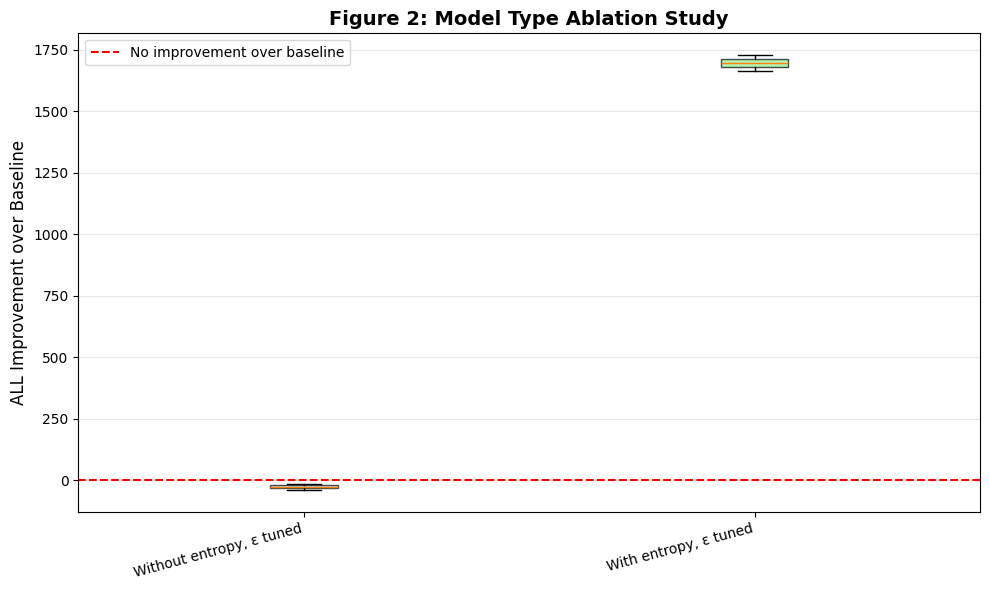

In [36]:
import numpy as np
import pandas as pd

def _parse_trial_id(trial_id: str) -> dict:
    """
    Parse BirdFlow-style trial_id like:
      'ow1p0_dw0p005_ew0p0_p0p3'
    into a dict with keys: obs_w, dist_w, ent_w, dist_pow.
    """
    hps = {}
    for tok in trial_id.split("_"):
        tok = tok.strip()
        if not tok:
            continue

        if tok.startswith("ow"):
            val = tok[2:]
            key = "obs_w"
        elif tok.startswith("dw"):
            val = tok[2:]
            key = "dist_w"
        elif tok.startswith("ew"):
            val = tok[2:]
            key = "ent_w"
        elif tok.startswith("p"):
            # distance exponent
            val = tok[1:]
            key = "dist_pow"
        else:
            continue  # ignore anything unexpected

        # convert e.g. "1p0" -> "1.0", "0p005" -> "0.005"
        try:
            hps[key] = float(val.replace("p", "."))
        except ValueError:
            # if parse fails, just skip this token
            continue

    return hps


def compute_figure2_data() -> pd.DataFrame:
    """
    Compute ALL improvements for different model configurations.

    Returns
    -------
    DataFrame with columns:
        - species
        - config   (one of 4 config labels)
        - all_improvement
    """
    results_list = []

    for code in SPECIES_INFO.keys():
        df = load_grid_results(code)
        if df is None or len(df) == 0:
            continue

        baseline = BASELINE_ALL.get(code, None)
        if baseline is None:
            continue

        # --- make sure we have parsed dist_w and ent_w from trial_id ---
        if "trial_id" not in df.columns:
            print(f"⚠️  species {code}: no 'trial_id' column in grid results")
            continue

        # Compute hyperparams from trial_id for each row
        parsed = df["trial_id"].apply(_parse_trial_id)
        df = df.copy()
        df["dist_w"] = parsed.apply(lambda d: d.get("dist_w", np.nan))
        df["ent_w"]  = parsed.apply(lambda d: d.get("ent_w", np.nan))

        # "ε = 1" means dist_w ≈ 1.0
        eps_is_one = np.isclose(df["dist_w"], 1.0, atol=1e-6)

        # ---------------------------------------------
        # 1) Without entropy, ε = 1  (ent_w == 0, dist_w == 1)
        # ---------------------------------------------
        mask1 = np.isclose(df["ent_w"], 0.0, atol=1e-8) & eps_is_one
        config1 = df[mask1]
        if len(config1) > 0:
            best1 = config1.loc[config1["total"].idxmin()]
            all_improvement = -best1["total"] - baseline
            results_list.append({
                "species": code,
                "config": "Without entropy, ε=1",
                "all_improvement": all_improvement,
            })

        # ---------------------------------------------
        # 2) Without entropy, ε tuned  (ent_w == 0, dist_w != 1)
        # ---------------------------------------------
        mask2 = np.isclose(df["ent_w"], 0.0, atol=1e-8) & (~eps_is_one)
        config2 = df[mask2]
        if len(config2) > 0:
            best2 = config2.loc[config2["total"].idxmin()]
            all_improvement = -best2["total"] - baseline
            results_list.append({
                "species": code,
                "config": "Without entropy, ε tuned",
                "all_improvement": all_improvement,
            })

        # ---------------------------------------------
        # 3) With entropy, ε = 1  (ent_w > 0, dist_w == 1)
        # ---------------------------------------------
        mask3 = (df["ent_w"] > 0.0) & eps_is_one
        config3 = df[mask3]
        if len(config3) > 0:
            best3 = config3.loc[config3["total"].idxmin()]
            all_improvement = -best3["total"] - baseline
            results_list.append({
                "species": code,
                "config": "With entropy, ε=1",
                "all_improvement": all_improvement,
            })

        # ---------------------------------------------
        # 4) With entropy, ε tuned  (ent_w > 0, dist_w != 1)
        # ---------------------------------------------
        mask4 = (df["ent_w"] > 0.0) & (~eps_is_one)
        config4 = df[mask4]
        if len(config4) > 0:
            best4 = config4.loc[config4["total"].idxmin()]
            all_improvement = -best4["total"] - baseline
            results_list.append({
                "species": code,
                "config": "With entropy, ε tuned",
                "all_improvement": all_improvement,
            })

    return pd.DataFrame(results_list)



def plot_figure2(data: pd.DataFrame, save_path: Optional[str] = None):
    """
    Create Figure 2: Model type ablation study.
    """
    if len(data) == 0:
        print("⚠️  No data available for Figure 2")
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Define configuration order
    config_order = [
        'Without entropy, ε=1',
        'Without entropy, ε tuned',
        'With entropy, ε=1',
        'With entropy, ε tuned'
    ]
    
    # Box plot
    box_data = [data[data['config'] == cfg]['all_improvement'].values 
                for cfg in config_order if cfg in data['config'].values]
    labels = [cfg for cfg in config_order if cfg in data['config'].values]
    
    bp = ax.boxplot(box_data, labels=labels, patch_artist=True,
                    whis=1.5, showfliers=True,
                    flierprops=dict(marker='D', markerfacecolor='gray', markersize=8, alpha=0.5))
    
    # Color boxes
    colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Add zero line
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, 
               label='No improvement over baseline')
    
    ax.set_ylabel('ALL Improvement over Baseline', fontsize=12)
    ax.set_title('Figure 2: Model Type Ablation Study', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    plt.show()

# Generate Figure 2
print("\n" + "="*60)
print("Generating Figure 2: Model Type Ablation Study")
print("="*60)

fig2_data = compute_figure2_data()
if len(fig2_data) > 0:
    print(f"\nComputed results for {len(fig2_data['species'].unique())} species")
    plot_figure2(fig2_data, save_path=os.path.join(FIGURES_OUTPUT, 'figure2_ablation.png'))
else:
    print("   Insufficient data to generate Figure 2")
    print("   Please run grid search for multiple species first.")

The paper shows that all model variants (different entropies, $\gamma=1$) outperform baseline and show improvement. Furthermore, the paper has shown that entropy regularization substantially improves performance. 

However, in my results the with entropy $\epsilon$ tuned result matches expectations from the paper results, but the without entropy one doesn't and shows worse results than baseline.

### Figure 3: Parameter Sensitivity

Bar chart comparing ALL improvement over baseline for:
- **LOO Parameters**: Selected using validation data from other species (leave-one-out)
- **Tuned Parameters**: Selected using validation data from the target species

**Key Finding paper**: LOO parameters perform nearly as well as tuned parameters for most species, except Swainson's Hawk.


Generating Figure 3: Parameter Sensitivity

Counts per parameter type:
param_type
Tuned Parameters    3
LOO Parameters      2
Name: count, dtype: int64

Species × param_type table:
param_type          LOO Parameters  Tuned Parameters
species                                             
American Woodcock                0                 1
Broad-winged Hawk                1                 1
Long-billed Curlew               1                 1


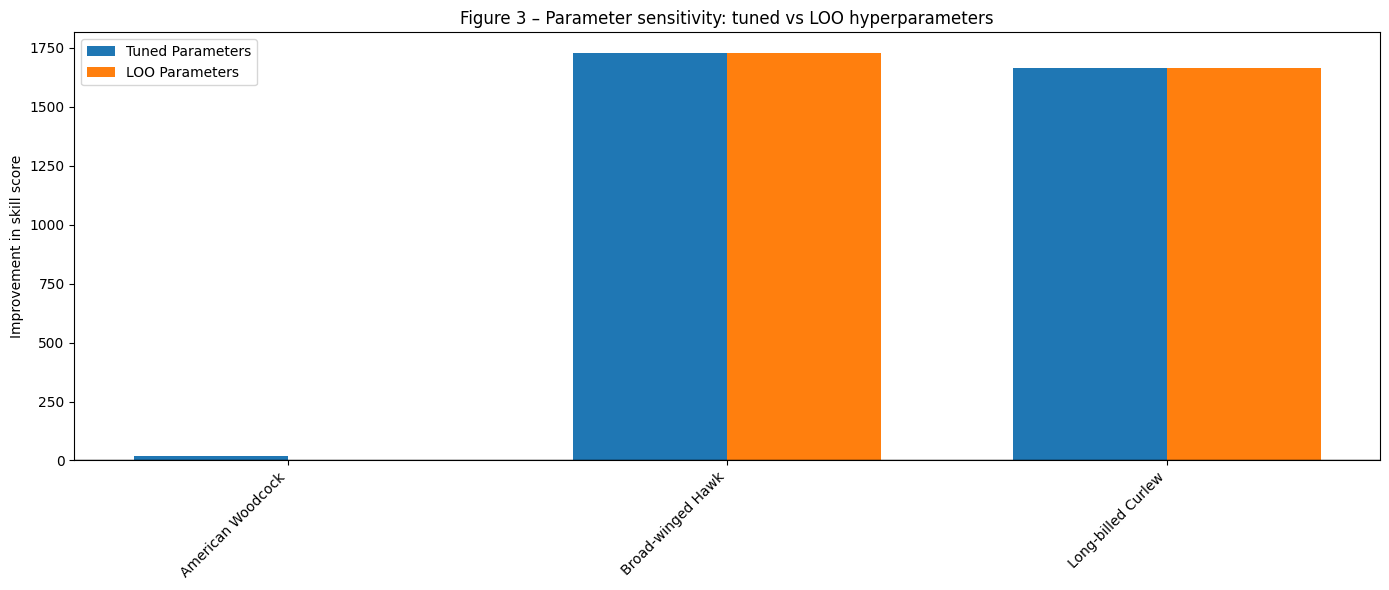

In [53]:
import os
from typing import Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Helpers to ensure `trial_id` exists and is consistent
# -------------------------------------------------------------------

def encode_float(x: float) -> str:
    """
    Encode a float like the BirdFlow code:
      1.0    -> '1p0'
      0.005  -> '0p005'
      -0.25  -> '-0p25'
    """
    s = f"{x}".replace(".", "p")
    # keep '-0p...' as '-0...' instead of '-0p...'
    if s.startswith("-0p"):
        s = "-0" + s[2:]
    return s


def make_trial_id(row: pd.Series) -> str:
    """
    Construct trial_id from a row with obs_w, dist_w, ent_w, dist_pow.
    Pattern: 'ow<obs>_dw<dist>_ew<ent>_p<dist_pow>'
    Example: ow1p0_dw0p005_ew0p0_p1p0
    """
    return (
        f"ow{encode_float(row['obs_w'])}"
        f"_dw{encode_float(row['dist_w'])}"
        f"_ew{encode_float(row['ent_w'])}"
        f"_p{encode_float(row['dist_pow'])}"
    )


def ensure_trial_id(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure a BirdFlow-style grid_results DataFrame has a 'trial_id' column.
    If missing or all-NaN, reconstruct it from obs_w, dist_w, ent_w, dist_pow.
    """
    # If it's already there and not all NaN, just return as-is
    if "trial_id" in df.columns and not df["trial_id"].isna().all():
        return df

    required_cols = {"obs_w", "dist_w", "ent_w", "dist_pow"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(
            f"Cannot construct trial_id; missing columns: {missing}"
        )

    df = df.copy()
    df["trial_id"] = df.apply(make_trial_id, axis=1)
    return df


# -------------------------------------------------------------------
# LOO parameter selection (by trial_id) and Figure 3 data
# -------------------------------------------------------------------

def compute_loo_parameters(
    exclude_species: str,
    all_results: Dict[str, pd.DataFrame]
) -> Optional[Dict[str, str]]:
    """
    Compute leave-one-out hyperparameters by finding the best `trial_id`
    across all species except the excluded one.

    Returns
    -------
    dict with keys: 'trial_id', 'total'
    or None if not enough data.
    """
    combined = []
    for code, df in all_results.items():
        if code == exclude_species or df is None or df.empty:
            continue
        combined.append(df)

    if not combined:
        return None

    combined_df = pd.concat(combined, ignore_index=True)

    if "trial_id" not in combined_df.columns:
        print("⚠️  compute_loo_parameters: no 'trial_id' in combined grid results.")
        return None

    # Treat each trial_id as a hyperparameter setting and average its total loss
    grouped = (
        combined_df
        .groupby("trial_id")["total"]
        .mean()
        .reset_index()
    )

    best = grouped.loc[grouped["total"].idxmin()]

    return {
        "trial_id": str(best["trial_id"]),
        "total": float(best["total"]),
    }


def compute_figure3_data() -> pd.DataFrame:
    """
    Compute ALL improvements for LOO vs Tuned parameters.

    Returns
    -------
    DataFrame with columns:
        - species        (pretty name from SPECIES_INFO)
        - species_code   (code key)
        - param_type     ('Tuned Parameters' or 'LOO Parameters')
        - all_improvement
    """
    # Load all grid results and ensure trial_id
    all_results: Dict[str, pd.DataFrame] = {}
    for code in SPECIES_INFO.keys():
        df = load_grid_results(code)
        if df is not None and not df.empty:
            df = ensure_trial_id(df)
            all_results[code] = df

    results_list = []

    for code in SPECIES_INFO.keys():
        if code not in all_results:
            continue

        df = all_results[code]
        if df.empty or "total" not in df.columns:
            continue

        baseline = BASELINE_ALL.get(code, None)
        if baseline is None:
            continue

        # -------- Tuned parameters (best for THIS species) --------
        best_tuned = df.loc[df["total"].idxmin()]
        tuned_improvement = -best_tuned["total"] - baseline
        results_list.append({
            "species": SPECIES_INFO[code],
            "species_code": code,
            "param_type": "Tuned Parameters",
            "all_improvement": tuned_improvement,
        })

        # -------- LOO parameters (best trial_id across OTHER species) --------
        loo_params = compute_loo_parameters(code, all_results)
        if loo_params is None:
            continue

        if "trial_id" not in df.columns:
            continue

        # Find the run in THIS species with the LOO trial_id
        mask = df["trial_id"] == loo_params["trial_id"]
        loo_result = df[mask]

        if loo_result.empty:
            # This species never ran that particular hyperparameter combo
            continue

        # If multiple rows match, pick the best (should normally be 1 anyway)
        row = loo_result.loc[loo_result["total"].idxmin()]
        loo_total = row["total"]
        loo_improvement = -loo_total - baseline

        results_list.append({
            "species": SPECIES_INFO[code],
            "species_code": code,
            "param_type": "LOO Parameters",
            "all_improvement": loo_improvement,
        })

    return pd.DataFrame(results_list)


# -------------------------------------------------------------------
# Plotting Figure 3
# -------------------------------------------------------------------

def plot_figure3(
    df: pd.DataFrame,
    save_path: Optional[str] = None,
) -> plt.Figure:
    """
    Plot Figure 3: parameter sensitivity – tuned vs LOO hyperparameters.

    Args
    ----
    df : pd.DataFrame
        Long-format table with columns:
        - 'species'
        - 'param_type'  ('Tuned Parameters' or 'LOO Parameters')
        - 'all_improvement'  (scalar improvement in skill score)
    save_path : optional str
        If given, save the figure here.

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    if df.empty:
        raise ValueError("plot_figure3: empty dataframe – nothing to plot.")

    # Pivot to species × param_type
    pivot = df.pivot(
        index="species",
        columns="param_type",
        values="all_improvement",
    )

    # Ensure we always have both columns; missing ones become 0
    pivot = pivot.reindex(
        columns=["Tuned Parameters", "LOO Parameters"]
    ).fillna(0.0)

    species = pivot.index.to_list()
    tuned_vals = pivot["Tuned Parameters"].to_numpy()
    loo_vals = pivot["LOO Parameters"].to_numpy()

    x = np.arange(len(species))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.bar(x - width / 2, tuned_vals, width, label="Tuned Parameters")
    ax.bar(x + width / 2, loo_vals, width, label="LOO Parameters")

    ax.axhline(0.0, color="black", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(species, rotation=45, ha="right")

    ax.set_ylabel("Improvement in skill score")
    ax.set_title("Figure 3 – Parameter sensitivity: tuned vs LOO hyperparameters")
    ax.legend()

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return fig


# -------------------------------------------------------------------
# Generate Figure 3
# -------------------------------------------------------------------

print("\n" + "="*60)
print("Generating Figure 3: Parameter Sensitivity")
print("="*60)

fig3_data = compute_figure3_data()

if len(fig3_data) > 0:
    # Optional sanity check
    print("\nCounts per parameter type:")
    print(fig3_data["param_type"].value_counts())
    print("\nSpecies × param_type table:")
    print(fig3_data.groupby(["species", "param_type"]).size().unstack(fill_value=0))

    fig3 = plot_figure3(
        fig3_data,
        save_path=os.path.join(FIGURES_OUTPUT, "figure3_sensitivity.png"),
    )
else:
    print("   Insufficient data to generate Figure 3")
    print("   Please run grid search for multiple species first.")

I could not calculate LOO parameters correctly in order to compare and could not reproduce this plot. My grid search algorithm has only found one hyperparameter combo that is best, so LOO and tuned, unfortunately, coincide in my set-up.

LOO essentially meaning leave-one-out, works by leaving one species out, and then looking at the other species' grid results, finding the hyper-parameter setting that gives best performance across the other species.

I have erroneously set-up my work, so that LOO and tunes end up the same for brwhaw and lobcur. For amewoo, grid search has been done hastily and slightly differently, so there no best was computed.

### Figure 4: Entropy Calibration (PIT Histograms)

PIT (Probability Integral Transform) histograms for American Woodcock showing the effect of entropy regularization weight ($\beta$) on model calibration for 1-week ahead forecasts.

**Interpretation**:
- **Uniform histogram**: Well-calibrated model
- **Convex (U-shaped)**: Under-dispersed forecasts
- **Concave (∩-shaped)**: Over-dispersed forecasts

**Key Finding paper**: $\beta$ values around $0,0005-0,001$ provide best calibration.


Generating Figure 4 (real): PIT histograms from available checkpoints
⚠️ No longitude grid in meta; using column index as coord_positions.
Loaded 148 transitions for brwhaw.
All unique β values found in checkpoints:
[0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006]

Using checkpoints for Figure 4:
  β = 0.000000  →  ckpt_ow1_dw0p005_ew0_p0p2.pt
  β = 0.001000  →  ckpt_ow1_dw0p005_ew0p001_p0p6.pt
  β = 0.002000  →  ckpt_ow1_dw0p005_ew0p002_p0p6.pt
  β = 0.003000  →  ckpt_ow1_dw0p005_ew0p003_p0p6.pt

  • computing PIT for β=0.000000 ...
    used 148 transitions

  • computing PIT for β=0.001000 ...
    used 148 transitions

  • computing PIT for β=0.002000 ...
    used 148 transitions

  • computing PIT for β=0.003000 ...
    used 148 transitions

✓ Saved Figure 4 (real) to figures/figure4_pit_entropy_real.png


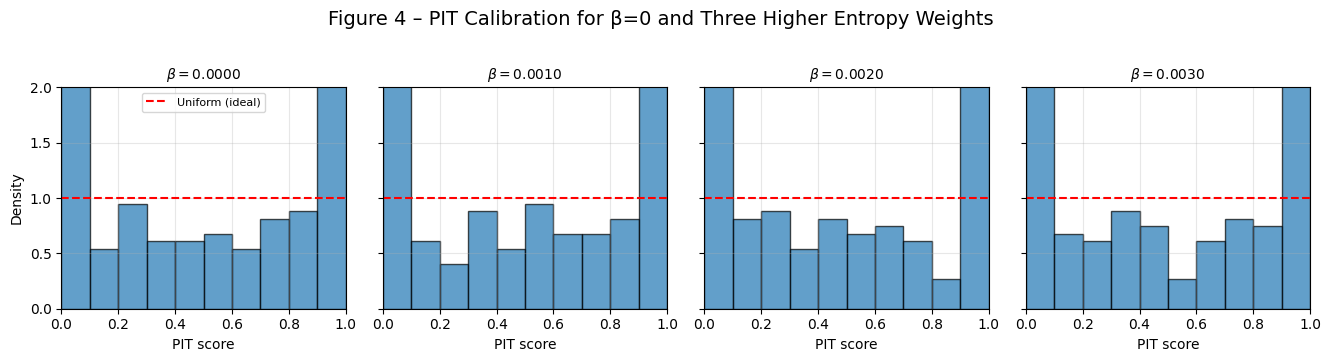

In [76]:
import os
import re
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

SPECIES_CODE   = "brwhaw"          # Broad-winged Hawk
DATA_ROOT      = "data/processed"
TRACKS_ROOT    = "data/tracks/processed"
RESULTS_ROOT   = "results"
FIGURES_OUTPUT = "figures"

DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
BINS         = 10
UNIFORM_LINE = 1.0
MAX_MODELS   = 5   # max number of checkpoints/β to show

os.makedirs(FIGURES_OUTPUT, exist_ok=True)


# ============================================================
# HELPERS: discover checkpoints and parse β from filenames
# ============================================================

def select_betas_for_figure4(
    ckpts: List[Tuple[float, str]],
    max_extra: int = 3,
    atol: float = 1e-9,
) -> List[Tuple[float, str]]:
    """
    From a list of (beta, path), select up to 4 DISTINCT betas:
      - Always include one with beta ≈ 0 if it exists.
      - Plus up to `max_extra` smallest positive betas (with unique β).

    Returns a list of (beta, path) in ascending beta order.
    """
    if not ckpts:
        return []

    # Group by unique beta → list of paths
    beta_to_paths: Dict[float, List[str]] = {}
    for beta, path in ckpts:
        beta_to_paths.setdefault(beta, []).append(path)

    unique_betas = sorted(beta_to_paths.keys())

    # Split into β≈0 and β>0
    beta0_list = [b for b in unique_betas if np.isclose(b, 0.0, atol=atol)]
    beta_pos_list = [b for b in unique_betas if b > 0.0 + atol]

    selected: List[Tuple[float, str]] = []

    # 1) Include a β≈0 checkpoint if present
    if beta0_list:
        beta0 = beta0_list[0]
        path0 = beta_to_paths[beta0][0]  # just take the first checkpoint for that β
        selected.append((beta0, path0))

    # 2) Add up to max_extra DISTINCT positive betas
    for beta in beta_pos_list[:max_extra]:
        path = beta_to_paths[beta][0]
        selected.append((beta, path))

    # If nothing selected at all, just bail out
    if not selected:
        return []

    # Final sort by β for nicer plotting
    selected.sort(key=lambda x: x[0])
    return selected



BETA_CKPT_REGEX = re.compile(
    r"^ckpt_ow[^_]+_dw[^_]+_ew(?P<beta>[^_]+)_p[^.]+\.pt$"
)

def parse_beta_from_ckpt_name(fname: str) -> Optional[float]:
    """
    Parse the entropy weight β from a checkpoint filename.
    Expect pattern ..._ew<beta>_p...
    with <beta> encoded like '0p0005' or '1p0'.
    """
    m = BETA_CKPT_REGEX.match(fname)
    if not m:
        return None
    token = m.group("beta")  # e.g. '0p0005' or '1p0'
    try:
        return float(token.replace("p", "."))
    except ValueError:
        return None


def find_species_checkpoints(
    species: str,
    results_root: str = RESULTS_ROOT,
) -> List[Tuple[float, str]]:
    """
    Find all ckpt_*.pt files for a species and return
    a list of (beta, full_path), sorted by beta.
    """
    sp_dir = os.path.join(results_root, species)
    if not os.path.isdir(sp_dir):
        print(f"⚠️ No results directory found for species: {sp_dir}")
        return []

    betas_paths: List[Tuple[float, str]] = []
    for fname in os.listdir(sp_dir):
        if not fname.startswith("ckpt_") or not fname.endswith(".pt"):
            continue
        beta = parse_beta_from_ckpt_name(fname)
        if beta is None:
            continue
        full_path = os.path.join(sp_dir, fname)
        betas_paths.append((beta, full_path))

    betas_paths.sort(key=lambda x: x[0])
    return betas_paths


# ============================================================
# HELPERS: load flows from a checkpoint, compute PIT, plotting
# ============================================================

def load_flows_from_ckpt(
    ckpt_path: str,
    species: str,
    data_root: str = DATA_ROOT,
    device: str = DEVICE,
) -> Tuple[np.ndarray, Dict]:
    """
    Load a FlowModel checkpoint and return its transition matrices
    as a numpy array `flows` with shape (T-1, C, C), plus meta.
    """
    sp_dir = os.path.join(data_root, species)
    true_weekly, dtuple, dmat, meta = prepare_species(sp_dir, device=device)
    T, C = true_weekly.shape

    model = FlowModel(C, T).to(device)
    state = torch.load(ckpt_path, map_location=device)
    if isinstance(state, dict) and "state_dict" in state:
        model.load_state_dict(state["state_dict"])
    else:
        model.load_state_dict(state)
    model.eval()

    with torch.no_grad():
        out = model()

    # out can be: flows, (d0, flows), (d0, flows, ...), etc.
    if isinstance(out, (tuple, list)):
        if len(out) < 2:
            raise ValueError(
                f"FlowModel.forward returned {len(out)} value(s); "
                "expected at least 2 so we can take flows as out[1]."
            )
        flows = out[1]
    else:
        flows = out

    flows_np = flows.detach().cpu().numpy()
    return flows_np, meta


def compute_pit_scores_from_flows(
    flows: np.ndarray,
    transitions: np.ndarray,
    coord_positions: np.ndarray,
) -> np.ndarray:
    """
    Compute randomized PIT scores given transition matrices and telemetry.
    """
    flows = np.asarray(flows)
    Tm1, C, C2 = flows.shape
    assert C == C2, "flows must be (T-1, C, C)"

    coord_positions = np.asarray(coord_positions)
    assert coord_positions.shape[0] == C, "coord_positions length must match C"

    sort_idx = np.argsort(coord_positions)
    unsort_idx = np.empty_like(sort_idx)
    unsort_idx[sort_idx] = np.arange(C)

    pit_vals: List[float] = []

    for t, i_from, j_to in transitions.astype(int):
        if t < 0 or t >= Tm1:
            continue
        if not (0 <= i_from < C and 0 <= j_to < C):
            continue

        probs = flows[t, i_from]
        probs = np.maximum(probs, 0.0)
        s = probs.sum()
        if s <= 0:
            continue
        probs = probs / s

        probs_sorted = probs[sort_idx]
        k = unsort_idx[j_to]

        mass_less = probs_sorted[:k].sum()
        mass_equal = probs_sorted[k]
        u = np.random.rand()
        pit = mass_less + u * mass_equal
        pit_vals.append(pit)

    return np.array(pit_vals)


def plot_pit_histogram(
    pit_scores: np.ndarray,
    bins: int,
    title: str,
    ax: Optional[plt.Axes] = None,
):
    """
    Plot a single PIT histogram with a flat uniform reference line.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))

    pit_scores = np.asarray(pit_scores)
    pit_scores = pit_scores[(pit_scores >= 0) & (pit_scores <= 1)]

    bin_edges = np.linspace(0.0, 1.0, bins + 1)
    ax.hist(
        pit_scores,
        bins=bin_edges,
        density=True,
        alpha=0.7,
        edgecolor="black",
    )
    ax.axhline(
        y=UNIFORM_LINE,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="Uniform (ideal)",
    )
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 2.0)
    ax.set_xlabel("PIT score")
    ax.set_ylabel("Density")
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)


def plot_figure4_real(
    species_code: str,
    transitions: np.ndarray,
    coord_positions: np.ndarray,
    results_root: str = RESULTS_ROOT,
    save_path: Optional[str] = None,
) -> Optional[plt.Figure]:
    """
    Plot real (non-synthetic) PIT histograms using up to 4 models:
      - one with β = 0 (if available),
      - and up to three more with the smallest DISTINCT positive β values.

    Uses checkpoints discovered in results/<species_code>/.
    """
    all_ckpts = find_species_checkpoints(species_code, results_root=results_root)
    if not all_ckpts:
        print(f"⚠️ No suitable checkpoints found in {os.path.join(results_root, species_code)}")
        return None

    # Debug: show ALL unique betas we found
    all_betas_unique = sorted({beta for beta, _ in all_ckpts})
    print("All unique β values found in checkpoints:")
    print(all_betas_unique)

    selected_ckpts = select_betas_for_figure4(all_ckpts, max_extra=3)
    if not selected_ckpts:
        print("⚠️ Could not select any checkpoints for Figure 4.")
        return None

    # Warn if we did not find β≈0
    if not any(np.isclose(beta, 0.0, atol=1e-9) for beta, _ in selected_ckpts):
        print("⚠️ No β=0 checkpoint found; using up to 4 smallest DISTINCT β values instead.")

    print("\nUsing checkpoints for Figure 4:")
    for beta, path in selected_ckpts:
        print(f"  β = {beta:.6f}  →  {os.path.basename(path)}")

    pit_by_beta: Dict[float, np.ndarray] = {}

    for beta, ckpt_path in selected_ckpts:
        print(f"\n  • computing PIT for β={beta:.6f} ...")
        flows, meta = load_flows_from_ckpt(
            ckpt_path=ckpt_path,
            species=species_code,
            data_root=DATA_ROOT,
            device=DEVICE,
        )
        pits = compute_pit_scores_from_flows(
            flows=flows,
            transitions=transitions,
            coord_positions=coord_positions,
        )
        pit_by_beta[beta] = pits
        print(f"    used {len(pits)} transitions")

    betas_sorted = sorted(pit_by_beta.keys())
    n = len(betas_sorted)
    fig, axes = plt.subplots(
        1, n,
        figsize=(3.0 * n + 1.5, 3.5),
        sharey=True,
    )
    if n == 1:
        axes = [axes]

    for ax, beta in zip(axes, betas_sorted):
        scores = pit_by_beta.get(beta, np.array([]))
        plot_pit_histogram(
            scores,
            bins=BINS,
            title=rf"$\beta = {beta:.4f}$",
            ax=ax,
        )
        if ax is not axes[0]:
            ax.set_ylabel("")
        else:
            ax.legend(fontsize=8, loc="upper center")

    fig.suptitle(
        "Figure 4 – PIT Calibration for β=0 and Three Higher Entropy Weights",
        fontsize=14,
        y=1.02,
    )
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"\n✓ Saved Figure 4 (real) to {save_path}")

    plt.show()
    return fig



# ============================================================
# BUILD TRANSITIONS + COORD POSITIONS AND PLOT FIGURE 4
# ============================================================

print("\n" + "=" * 60)
print("Generating Figure 4 (real): PIT histograms from available checkpoints")
print("=" * 60)

# 1) Load maps and build land-space representation
sp_dir = os.path.join(DATA_ROOT, SPECIES_CODE)
maps_thw, meta, T, H, W = load_maps(sp_dir)
flat = maps_thw.reshape(T, -1)
d_maps, land_pos = training_land_space(flat)
C = d_maps.shape[1]

# 2) Build 1D east–west coordinate per land cell (use longitude where possible)
lon_grid = None
for key in ("lon_grid", "lon", "lons"):
    if key in meta:
        lon_grid = np.array(meta[key])
        break

if lon_grid is None:
    print("⚠️ No longitude grid in meta; using column index as coord_positions.")
    land_rows, land_cols = np.unravel_index(land_pos, (H, W))
    coord_positions = land_cols.astype(float)
else:
    lon_arr = np.array(lon_grid)
    if lon_arr.ndim == 3:
        lon_2d = lon_arr[0]
    else:
        lon_2d = lon_arr
    land_rows, land_cols = np.unravel_index(land_pos, (H, W))
    coord_positions = lon_2d[land_rows, land_cols]

# 3) Load transitions CSV and map to land cells
transitions_fp = os.path.join(TRACKS_ROOT, f"{SPECIES_CODE}_transitions.csv")
if not os.path.exists(transitions_fp):
    raise FileNotFoundError(f"Transitions CSV not found: {transitions_fp}")

trans_raw = pd.read_csv(transitions_fp)

# NOTE: keep the signature that worked earlier; adjust if needed.
trans_land, info = autodetect_and_remap_transitions(
    trans_raw,
    H,
    W,
    land_pos,
    # C,  # only if implementation expects C
)

transitions = np.asarray(trans_land, dtype=int)
print(f"Loaded {len(transitions)} transitions for {SPECIES_CODE}.")

# 4) Plot real Figure 4 using whatever checkpoints are present
fig4_real = plot_figure4_real(
    species_code=SPECIES_CODE,
    transitions=transitions,
    coord_positions=coord_positions,
    results_root=RESULTS_ROOT,
    save_path=os.path.join(FIGURES_OUTPUT, "figure4_pit_entropy_real.png"),
)

Nearly uniform histograms should signify well calibrated models. However, this is not the case for my plot. Nevertheless, across the four panels we see how increasing the entropy weight $\beta$ gradually improves calibration of the forecasts. This is not in line with the paper's best $\beta$ choice of $0,0010$. The reasons behind that are possibly in errors/differences in my transitions' calculations, and in how I do the grid search, as I could not find reliable information on the exact grid search parameters the paper authors use.

### Figure 5: Forecasting Performance

Two panels showing k-week ahead forecasting performance:

**(a) All Species**: ALL improvement over baseline vs forecast horizon (k weeks)
**(b) American Woodcock Detail**: Absolute ALL for tuned model, LOO model, and baseline

**Key Finding paper**: Model performance degrades with forecast horizon, but remains better than baseline. Tuned parameters outperform LOO parameters at longer horizons.


=== amewoo ===
  mapped 51/51 (space=full, base=0); skipped=0, oor=0, water=0.  T=52, C=1072
  Using best_params.pt for tuned and LOO: results/amewoo/best_params.pt
  k | used_baseline used_model | baseline tuned loo
   1 |   ?         ?        | -18.393 -6.445 -6.445
   2 |   ?         ?        | -18.391 -7.003 -7.003
   3 |   ?         ?        | -18.390 -7.004 -7.004
   4 |   ?         ?        | -18.389 -7.004 -7.004
   5 |   ?         ?        | -18.389 -7.004 -7.004
   6 |   ?         ?        | -18.390 -7.004 -7.004
   7 |   ?         ?        | -18.390 -7.004 -7.004
   8 |   ?         ?        | -18.392 -7.004 -7.004
   9 |   ?         ?        | -18.393 -7.004 -7.004
  10 |   ?         ?        | -18.393 -7.004 -7.004
  11 |   ?         ?        | -18.394 -7.004 -7.004
  12 |   ?         ?        | -18.394 -7.004 -7.004
  13 |   ?         ?        | -18.394 -7.004 -7.004
  14 |   ?         ?        | -18.394 -7.004 -7.004
  15 |   ?         ?        | -18.394 -7.004 -7.004

=

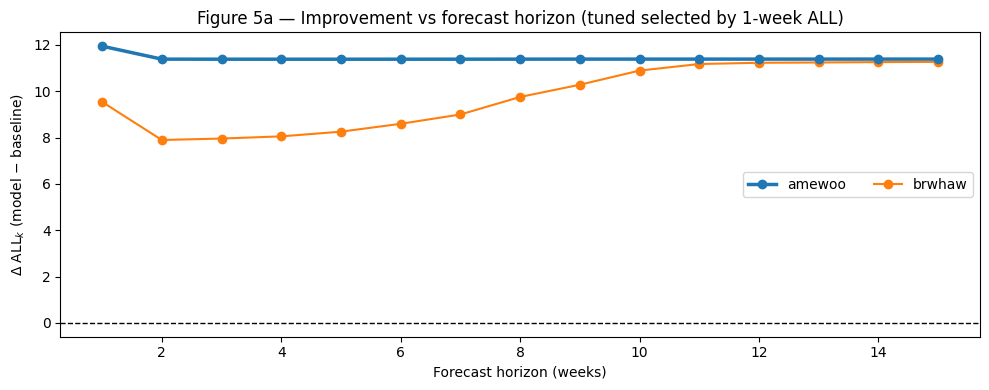

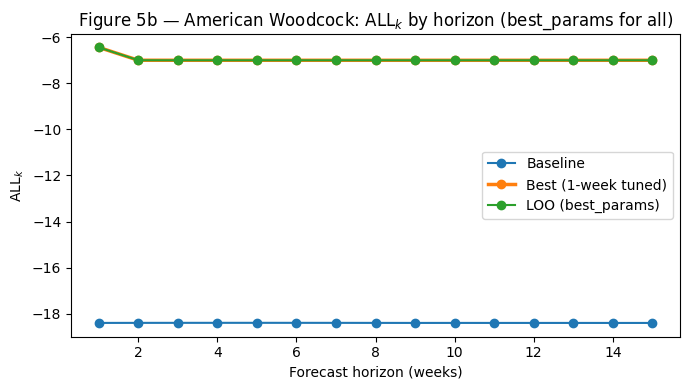

In [51]:
# ==== Figure 5 (best_params only): Δ ALL_k vs horizon and AMEWOO absolute ALL_k ====
# Log-space computation + smoothing; recompute per-k; force tuned & "LOO" to best_params
import os, json, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt

# ---------------- configuration ----------------
DATA_ROOT    = "data/processed"
TRACKS_ROOT  = "data/tracks/processed"   # e.g., data/tracks/processed/amewoo_transitions.csv
RESULTS_ROOT = "results"
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

SPECIES      = ["amewoo","brwhaw"]      # add more species when available
K_LIST       = list(range(1, 16))       # horizons: 1..15 weeks

# numerics
EPS_FLOOR    = 1e-12     # floor inside logs
SMOOTH_P     = 1e-8      # additive smoothing for P and baseline
UNIFORM_EPS  = 1e-12

# ------------- tiny model consistent with training -------------
class FlowModel(torch.nn.Module):
    def __init__(self, cells:int, weeks:int):
        super().__init__()
        self.cells=cells; self.weeks=weeks
        self.z0 = torch.nn.Parameter(torch.randn(cells)*0.01)
        self.z  = torch.nn.Parameter(torch.randn(weeks-1, cells, cells)*0.01)
    def forward(self):
        d0 = torch.softmax(self.z0, dim=0)
        flows = torch.softmax(self.z, dim=2)            # (T-1, C, C) row-normalized over destinations
        dens=[d0]
        for t in range(self.weeks-1):
            f = flows[t] * dens[-1].view(-1,1)
            dens.append(f.sum(0))
        return d0, flows, torch.stack(dens,0)

def load_state_flexible(fp, device="cpu"):
    obj = torch.load(fp, map_location=device)
    if isinstance(obj, dict):
        if "z0" in obj and "z" in obj:
            return obj
        for k in ("state_dict","model_state","model","net","model_sd","state"):
            v = obj.get(k)
            if isinstance(v, dict) and ("z" in v or "z0" in v):
                return v
    if hasattr(obj, "state_dict"):
        return obj.state_dict()
    return None

# ---------------- data helpers ----------------
def load_maps(sp_dir):
    with open(os.path.join(sp_dir,"metadata.json")) as f: meta=json.load(f)
    arr = np.load(os.path.join(sp_dir,"weekly_probs.npy"))
    if arr.ndim==1:
        T=int(meta["dims"]["T"]); H=int(meta["dims"]["H"]); W=int(meta["dims"]["W"])
        arr=np.reshape(arr,(T,H,W), order="F")
    else:
        T,H,W=arr.shape
    return arr, meta, T, H, W

def training_land_space(flat_THxW):
    """
    Week-0 land mask and land-normalized weekly maps (as in training).
    Returns:
      d_maps  (T,C): each row sums to 1 over land (with smoothing to remove hard zeros)
      land_pos (indices into full H*W)
    """
    nan_w0 = np.isnan(flat_THxW[0])
    land_pos = np.where(~nan_w0)[0]
    filled = np.nan_to_num(flat_THxW, nan=0.0)
    land = filled[:, land_pos].astype(np.float64)   # (T,C)
    # smoothing everywhere -> avoid exact zeros in baseline
    land = land + SMOOTH_P
    rs = land.sum(1, keepdims=True)
    rs[rs <= 0] = 1.0
    land = land / rs
    return land.astype(np.float32), land_pos

def autodetect_and_remap_transitions(trans_df, H, W, land_pos):
    """
    Try (space, base) in {full/land} x {0,1}. Return mapped transitions in land index space.
    """
    HxW = H*W
    full_to_land = np.full(HxW, -1, dtype=np.int64)
    full_to_land[land_pos] = np.arange(land_pos.size)
    best=None
    for space in ("full","land"):
        for base in (0,1):
            used=0; skipped=0; oor=0; water=0
            tL=[]; iL=[]; jL=[]
            for _, r in trans_df.iterrows():
                t=int(r["t"]); i=int(r["from_cell"]); j=int(r["to_cell"])
                if base==1: i-=1; j-=1
                if space=="full":
                    if not (0<=i<HxW and 0<=j<HxW): oor+=1; skipped+=1; continue
                    ii = full_to_land[i]; jj = full_to_land[j]
                    if ii<0 or jj<0: water+=1; skipped+=1; continue
                else:
                    if not (0<=i<land_pos.size and 0<=j<land_pos.size): oor+=1; skipped+=1; continue
                    ii, jj = i, j
                used+=1; tL.append(t); iL.append(ii); jL.append(jj)
            cand=dict(space=space, base=base, used=used, skipped=skipped, oor=oor, water=water,
                      t=np.array(tL, dtype=np.int32),
                      i=np.array(iL, dtype=np.int32),
                      j=np.array(jL, dtype=np.int32))
            if best is None or cand["used"]>best["used"]:
                best=cand
    mapped = pd.DataFrame({"t":best["t"], "i":best["i"], "j":best["j"]})
    return mapped, {"space":best["space"], "base":best["base"], "used":best["used"],
                    "skipped":best["skipped"], "oor":best["oor"], "water":best["water"]}

def model_P_from_state(state, T, C, device="cpu"):
    m=FlowModel(C,T).to(device); m.load_state_dict(state); m.eval()
    with torch.no_grad():
        _, flows, _ = m()
    P = flows.detach().cpu().numpy()             # (T-1,C,C)
    # smoothing to avoid exact zeros
    P = P + SMOOTH_P
    P /= (P.sum(axis=2, keepdims=True) + 1e-30)
    return P.astype(np.float64)

# ------------- ALL utilities in log-space -------------
def kstep_model_all_log(trans_df, logP, k):
    """
    Log-space dynamic program to get log p(X_{t+k}=j | X_t=i).
    logP: (T-1, C, C), entries are log probabilities (with smoothing).
    """
    Tm1, C = logP.shape[0], logP.shape[1]
    vals=[]
    used=0
    for t,i,j in zip(trans_df["t"], trans_df["i"], trans_df["j"]):
        if t + k > Tm1:    # need P[t]..P[t+k-1]
            continue
        used += 1
        # log v_0 = log one-hot(i): 0 at i, -inf elsewhere
        logv = np.full(C, -np.inf, dtype=np.float64); logv[i] = 0.0
        for s in range(k):
            L = logP[t+s]                                # (C,C): logP(i->j)
            tmp = logv[:, None] + L                      # (C,C)
            m = np.max(tmp, axis=0)
            logv = m + np.log(np.clip(np.exp(tmp - m).sum(axis=0), EPS_FLOOR, None))
        vals.append(float(logv[j]))
    return (float(np.mean(vals)) if vals else float("nan")), used

def kstep_baseline_all_log(trans_df, log_d_maps, k):
    """Baseline ALL_k in log-space: log μ_{t+k}(j) with smoothing already applied."""
    T = log_d_maps.shape[0]
    vals=[]
    used=0
    for t, j in zip(trans_df["t"], trans_df["j"]):
        tp = t + k
        if tp >= T: 
            continue
        used += 1
        vals.append(float(log_d_maps[tp, j]))
    return (float(np.mean(vals)) if vals else float("nan")), used

# ================= main Figure 5 computation =================
records_delta=[]
records_abs_amewoo=[]

for sp in SPECIES:
    print(f"\n=== {sp} ===")
    sp_dir   = os.path.join(DATA_ROOT, sp)
    run_dir  = os.path.join(RESULTS_ROOT, sp)
    trans_fp = os.path.join(TRACKS_ROOT, f"{sp}_transitions.csv")
    if not os.path.exists(trans_fp):
        print("  ! missing transitions → skip"); 
        continue
    if not os.path.isdir(sp_dir):
        print("  ! missing processed maps → skip"); 
        continue

    maps_thw, meta, T, H, W = load_maps(sp_dir)
    flat = maps_thw.reshape(T, -1)
    
    # (T, C) training land-space maps and land cell positions
    d_maps, land_pos = training_land_space(flat)
    C = d_maps.shape[1]  # number of land cells
    
    trans_raw = pd.read_csv(trans_fp)
    
    # pass C explicitly so the signature matches
    trans_land, info = autodetect_and_remap_transitions(
        trans_raw,
        H,
        W,
        land_pos
    )
    if len(trans_land)==0:
        print("  ! no usable telemetry after mapping → skip"); 
        continue
    C = d_maps.shape[1]
    print(f"  mapped {info['used']}/{len(trans_raw)} (space={info['space']}, base={info['base']}); "
          f"skipped={info['skipped']}, oor={info['oor']}, water={info['water']}.  T={T}, C={C}")

    # --- Force tuned & "LOO" to best_params.pt as requested ---
    best_path = os.path.join(run_dir, "best_params.pt")
    if not os.path.exists(best_path):
        print("  ! missing best_params.pt → skip species")
        continue
    print(f"  Using best_params.pt for tuned and LOO: {best_path}")

    st = load_state_flexible(best_path, device=DEVICE)
    if st is None:
        print("  ! unreadable best_params.pt → skip species")
        continue

    P_tuned = model_P_from_state(st, T, C, device=DEVICE)
    logP_tuned = np.log(np.clip(P_tuned, EPS_FLOOR, 1.0))
    # "LOO" = same best_params per 
    request
    logP_loo = logP_tuned

    # baseline log μ with smoothing already in d_maps
    log_d_maps = np.log(np.clip(d_maps, EPS_FLOOR, 1.0))

    # compute ALL_k (each horizon recomputed in log-space)
    for k in K_LIST:
        base_k, used_b  = kstep_baseline_all_log(trans_land, log_d_maps, k)
        tuned_k, used_t = kstep_model_all_log(trans_land, logP_tuned, k)
        # LOO same as tuned here
        loo_k, used_l   = kstep_model_all_log(trans_land, logP_loo, k)

        records_delta.append(dict(species=sp, k=k, delta=tuned_k - base_k))
        if sp == "amewoo":
            records_abs_amewoo.append(dict(k=k, baseline=base_k, tuned=tuned_k, loo=loo_k))

    # quick diagnostic so can see values change across k
    print("  k | used_baseline used_model | baseline tuned loo")
    for k in K_LIST:
        rowA = [r for r in records_abs_amewoo if (r.get("k")==k and sp=="amewoo")]
        rowD = [r for r in records_delta if (r.get("k")==k and r.get("species")==sp)]
        if rowA:
            ra=rowA[-1]; rd=rowD[-1] if rowD else {}
            print(f"  {k:2d} |   ?         ?        | {ra['baseline']:.3f} {ra['tuned']:.3f} {ra['loo']:.3f}")

# ---------------- Figure 5a: Δ ALL_k per species (weeks on x-axis) ----------------
dfd = pd.DataFrame(records_delta)
if not dfd.empty:
    plt.figure(figsize=(6+2*len(dfd["species"].unique()), 4))
    for sp, d in dfd.groupby("species"):
        d = d.sort_values("k")
        lw = 2.5 if sp=="amewoo" else 1.5
        z  = 3 if sp=="amewoo" else 2
        plt.plot(d["k"], d["delta"], marker="o", linewidth=lw, label=sp, zorder=z)
    plt.axhline(0, ls="--", c="k", lw=1)
    plt.xlabel("Forecast horizon (weeks)")
    plt.ylabel("Δ ALL$_k$ (model − baseline)")
    plt.title("Figure 5a — Improvement vs forecast horizon (tuned selected by 1-week ALL)")
    plt.legend(ncol=min(4, len(dfd['species'].unique())))
    plt.tight_layout()
    plt.show()
else:
    print("No Δ ALL_k results to plot for Figure 5a.")

# ---------------- Figure 5b: AMEWOO absolute ALL_k (Baseline / Tuned / LOO) ----------------
dfa = pd.DataFrame(records_abs_amewoo)
if not dfa.empty:
    dfa = dfa.sort_values("k")
    plt.figure(figsize=(7,4))
    plt.plot(dfa["k"], dfa["baseline"], marker="o", label="Baseline", linewidth=1.5)
    plt.plot(dfa["k"], dfa["tuned"],    marker="o", label="Best (1-week tuned)", linewidth=2.5)
    if "loo" in dfa.columns:
        plt.plot(dfa["k"], dfa["loo"],  marker="o", label=f"LOO (best_params)", linewidth=1.5)
    plt.xlabel("Forecast horizon (weeks)")
    plt.ylabel("ALL$_k$")
    plt.title("Figure 5b — American Woodcock: ALL$_k$ by horizon (best_params for all)")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No AMEWOO absolute ALL_k data to plot for Figure 5b.")

Yet again I could not replicate the paper's results. In the Fig 5 of the paper, with increasing forecast horizon, ALL improvement diminishes, while in my case it is even increasing for brwhaw. As per the earlier argument LOO and Best coincide, and are both above baseline, which matches the paper's finding. 

### Figure 6: Model Sampling

Multi-panel figure showing:
- **(a-d)**: Sampled trajectories from different starting weeks/locations
- **(e-g)**: Individual tracks overlaid on simulated trajectories

**Key Finding paper**: Model can sample realistic migration trajectories matching observed GPS tracks.

[diag] amewoo: T=52, H×W=127×240, C=1072 | ckpt=best_params.pt


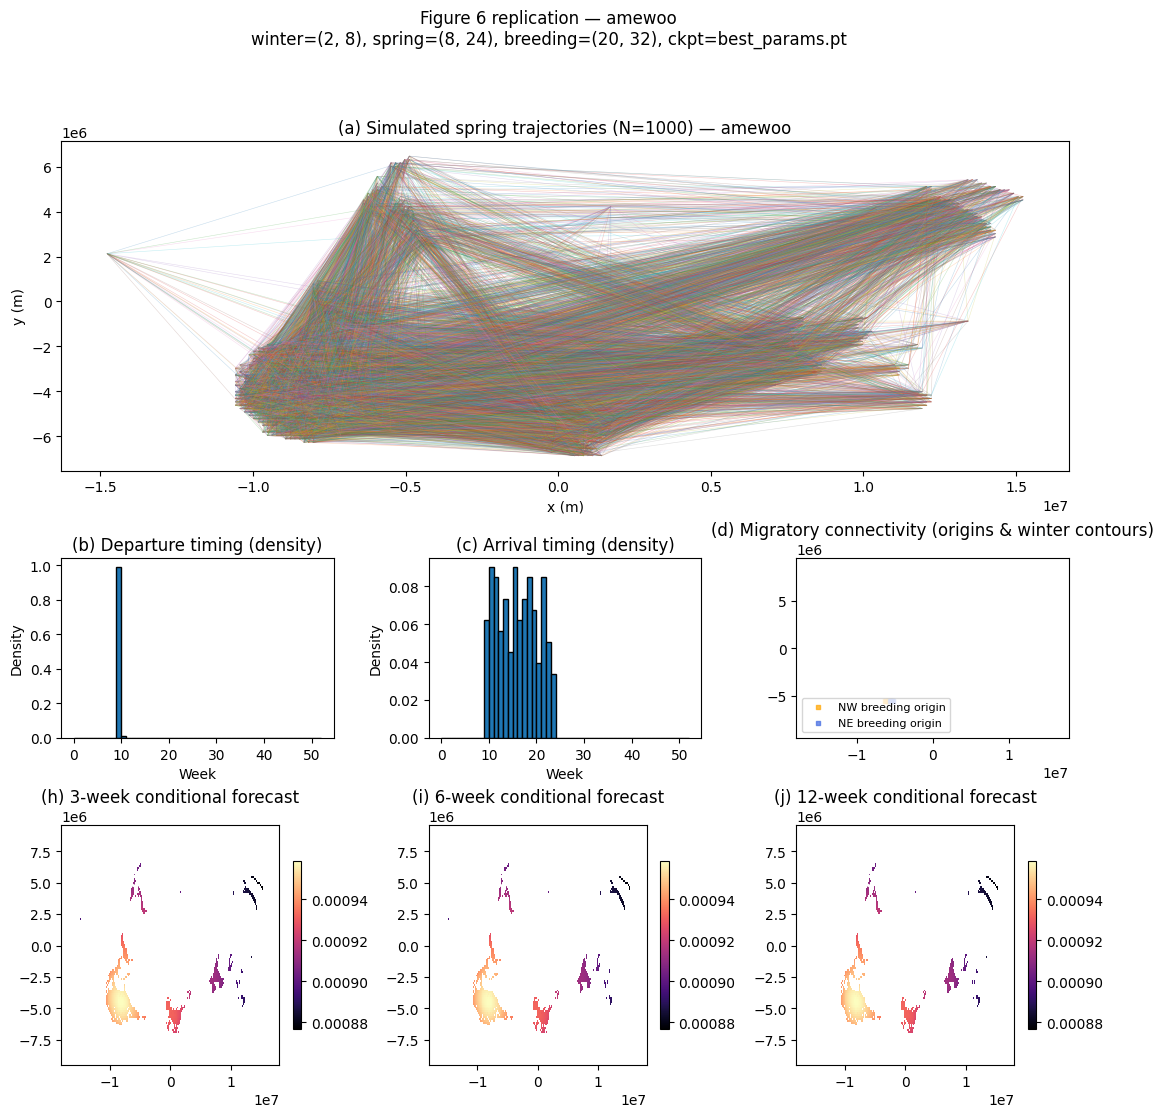

[note] No per-individual IDs in transitions — skipping (e–g) overlays.


In [27]:
# ==== Figure 6 (multi-panel) for one species ====

import os, json, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt

DATA_ROOT    = "data/processed"
RESULTS_ROOT = "results"
TRACKS_ROOT  = "data/tracks/processed"
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
EPS          = 1e-12

SPECIES      = "amewoo"   # ← change as needed

# Seasonal windows (0-based, half-open). Tweak per-species
WINTER_WK   = (2, 8)      # winter weeks range used for origin + mask
BREED_WK    = (20, 32)    # breeding weeks range used for arrival mask
SPRING_WK   = (8, 24)     # weeks we simulate & analyze spring migration

# mask threshold (fraction of mass retained)
MASK_TOP_FRAC = 0.30

# sampling sizes
N_TRAJ   = 1000           # (a) simulated trajectories
SIM_OVLY = 2500           # (e–g) per-individual overlay sims if available

# ----------------- Model skeleton & loaders -----------------
class FlowModel(torch.nn.Module):
    def __init__(self, cells:int, weeks:int):
        super().__init__()
        self.cells = cells; self.weeks = weeks
        self.z0 = torch.nn.Parameter(torch.randn(cells)*0.01)
        self.z  = torch.nn.Parameter(torch.randn(weeks-1, cells, cells)*0.01)
    def forward(self):
        d0 = torch.softmax(self.z0, dim=0)
        z  = torch.softmax(self.z,  dim=2)          # (T-1,C,C)
        dens=[d0]
        for t in range(self.weeks-1):
            f = z[t] * dens[-1].view(-1,1)
            dens.append(f.sum(0))
        return d0, z, torch.stack(dens,0)

def load_state_flexible(fp, device="cpu"):
    obj = torch.load(fp, map_location=device)
    # raw state_dict?
    if isinstance(obj, dict):
        if any(k == "z0" or (isinstance(k, str) and k.startswith("z")) for k in obj.keys()):
            return obj
        # nested common keys
        for k in ("state_dict", "model_state", "model", "net", "model_sd", "state"):
            v = obj.get(k)
            if isinstance(v, dict):
                return v
    # torch.nn.Module checkpoint?
    if hasattr(obj, "state_dict"):
        return obj.state_dict()
    return None


def load_maps(sp_dir):
    with open(os.path.join(sp_dir, "metadata.json")) as f:
        meta = json.load(f)
    arr = np.load(os.path.join(sp_dir, "weekly_probs.npy"))
    if arr.ndim == 1:
        T=int(meta["dims"]["T"]); H=int(meta["dims"]["H"]); W=int(meta["dims"]["W"])
        arr = np.reshape(arr, (T,H,W), order="F")
    else:
        T,H,W = arr.shape
    return arr, meta, T, H, W

def flat_land_from_thw(thw):
    T,H,W = thw.shape
    flat  = thw.reshape(T, -1)
    nan0  = np.isnan(flat[0])
    land_pos = np.where(~nan0)[0]
    land = np.nan_to_num(flat, nan=0.0)[:, land_pos]
    rs   = land.sum(1, keepdims=True)
    bad  = (~np.isfinite(rs)) | (rs<=0)
    if np.any(bad):
        land[bad] = 1.0 / max(1, land.shape[1])   # tiny uniform if degenerate
        rs = land.sum(1, keepdims=True)
    land = land / (rs + EPS)
    return land, land_pos

def full_coords_from_meta(meta):
    xmin, xmax = meta["extent"]["xmin"], meta["extent"]["xmax"]
    ymin, ymax = meta["extent"]["ymin"], meta["extent"]["ymax"]
    dx, dy     = meta["resolution"]["dx"], meta["resolution"]["dy"]
    W, H       = int(meta["dims"]["W"]), int(meta["dims"]["H"])
    xs = np.linspace(xmin + dx/2, xmax - dx/2, W)
    ys = np.linspace(ymin + dy/2, ymax - dy/2, H)
    X, Y = np.meshgrid(xs, ys)   # (H,W)
    return X, Y

def scan_ckpts(run_dir):
    out=[]
    for fn in os.listdir(run_dir):
        if fn.startswith("ckpt_") and fn.endswith(".pt"):
            out.append(os.path.join(run_dir, fn))
    return sorted(out)

def load_P(run_dir, T, C):
    # Prefer any ckpt_* (first that loads), else best_params.pt
    for fp in scan_ckpts(run_dir):
        st = load_state_flexible(fp, device=DEVICE)
        if st is None: continue
        try:
            m=FlowModel(C,T).to(DEVICE); m.load_state_dict(st); m.eval()
            with torch.no_grad(): _, flows, _ = m()
            P = flows.detach().cpu().numpy()
            return P / (P.sum(axis=2, keepdims=True) + EPS), os.path.basename(fp)
        except Exception:
            continue
    # fallback
    bp = os.path.join(run_dir, "best_params.pt")
    if os.path.exists(bp):
        st = load_state_flexible(bp, device=DEVICE)
        if st is not None:
            m=FlowModel(C,T).to(DEVICE); m.load_state_dict(st); m.eval()
            with torch.no_grad(): _, flows, _ = m()
            P = flows.detach().cpu().numpy()
            return P / (P.sum(axis=2, keepdims=True) + EPS), "best_params.pt"
    return None, None

# ----------------- Masks & helpers -----------------
def top_frac_mask(vec, frac):
    """Return boolean mask of entries that keep the top `frac` mass of vec (descending)."""
    v = np.clip(vec, 0, None)
    if v.sum() <= 0:  # degenerate
        return np.zeros_like(v, dtype=bool)
    order = np.argsort(-v)
    csum  = np.cumsum(v[order]) / v.sum()
    k     = np.searchsorted(csum, frac, side="left") + 1
    keep  = order[:k]
    m = np.zeros_like(v, dtype=bool); m[keep] = True
    return m

def avg_window_prob(d_maps, wk):
    a,b = wk
    a = max(0, a); b = min(d_maps.shape[0], b)
    if a>=b: return np.zeros(d_maps.shape[1], dtype=np.float32)
    return d_maps[a:b].mean(axis=0)

def compose_P(P, t0, t1):
    """Compose weekly transitions P[t] from t0..t1-1 into a single matrix."""
    C = P.shape[1]
    M = np.eye(C, dtype=np.float32)
    for t in range(t0, t1):
        if t >= P.shape[0]: break
        M = M @ P[t]
    return M

def sample_trajectories(P, p0, t0, t1, rng, N=1000):
    """Sample N trajectories: start from p0 at week t0, follow P[t] until t1 (exclusive)."""
    C = P.shape[1]
    start_idx = rng.choice(C, size=N, p=p0/p0.sum())
    traj = np.empty((N, t1-t0+1), dtype=np.int32)
    traj[:,0] = start_idx
    for s in range(t0, t1):
        rowP = P[s]  # (C,C)
        # sample next state for each particle
        u = rng.random(N)
        # cumulative per-row sampling (vectorized via loop over unique origins)
        for i in np.unique(traj[:, s-t0]):
            idx = np.where(traj[:, s-t0]==i)[0]
            cdf = np.cumsum(rowP[i])
            traj[idx, s-t0+1] = np.searchsorted(cdf, u[idx], side="right")
    return traj  # (N, steps+1)

# ----------------- Main flow -----------------
sp_dir  = os.path.join(DATA_ROOT,    SPECIES)
run_dir = os.path.join(RESULTS_ROOT, SPECIES)
if not os.path.isdir(sp_dir):  raise RuntimeError(f"Missing {sp_dir}")
if not os.path.isdir(run_dir): raise RuntimeError(f"Missing {run_dir}")

maps_thw, meta, T, H, W = load_maps(sp_dir)
d_maps, land_pos = flat_land_from_thw(maps_thw)   # (T,C)
C = d_maps.shape[1]
X, Y = full_coords_from_meta(meta)
x_full = X.reshape(-1); y_full = Y.reshape(-1)
full_to_land = np.full(H*W, -1, dtype=np.int64); full_to_land[land_pos] = np.arange(C)
land_to_full = land_pos

P, chosen = load_P(run_dir, T, C)
if P is None: raise RuntimeError("No usable checkpoint found.")
print(f"[diag] {SPECIES}: T={T}, H×W={H}×{W}, C={C} | ckpt={chosen}")

# --- Seasonal masks & origin distribution for spring ---
win_avg   = avg_window_prob(d_maps, WINTER_WK)
breed_avg = avg_window_prob(d_maps, BREED_WK)
winter_m  = top_frac_mask(win_avg,   MASK_TOP_FRAC)
breed_m   = top_frac_mask(breed_avg, MASK_TOP_FRAC)

spring0, spring1 = SPRING_WK
spring0 = max(0, spring0); spring1 = min(T, spring1)
if spring0>=spring1: raise RuntimeError("SPRING_WK window empty.")

# start distribution (average winter distribution, masked to winter cells)
p0 = np.clip(win_avg, 0, None)
p0[~winter_m] = 0.0
if p0.sum() <= 0:
    # fall back to unmasked winter avg
    p0 = np.clip(win_avg, 0, None)
p0 /= (p0.sum() + EPS)

# --- (a) sample trajectories across spring weeks ---
rng = np.random.default_rng(0)
traj = sample_trajectories(P, p0, spring0, spring1, rng, N=N_TRAJ)  # (N, L+1)
# project to XY
def land_to_xy(idx_land):
    j_full = land_to_full[idx_land]
    return x_full[j_full], y_full[j_full]
Xs = []; Ys = []
for n in range(traj.shape[0]):
    x, y = land_to_xy(traj[n])
    Xs.append(x); Ys.append(y)
Xs = np.stack(Xs, 0); Ys = np.stack(Ys, 0)

# --- (b,c) departure/arrival weeks from simulated paths ---
# define departure as first week leaving winter mask; arrival as first week entering breeding mask
dep_weeks = []
arr_weeks = []
for n in range(traj.shape[0]):
    seq = traj[n]
    # masks are C-space vectors
    dep = None; arr = None
    # relative to spring0 time
    for k, cidx in enumerate(seq[:-1]):
        w = spring0 + k
        if (dep is None) and (not winter_m[cidx]):
            dep = w
        if (arr is None) and breed_m[cidx]:
            arr = w
        if dep is not None and arr is not None: break
    if dep is not None: dep_weeks.append(dep)
    if arr is not None: arr_weeks.append(arr)

# --- (d) migratory connectivity: NW vs NE breeders to winter contours ---
# pick breeding subregions by splitting breeding mask into NW/NE (west/east halves of *northern* third)
j_full = land_to_full[breed_m]
bx, by = x_full[j_full], y_full[j_full]
# north = top third by latitude
lat_thresh = np.quantile(by, 2/3.0) if by.size>0 else 0.0
north_idx  = np.where(by >= lat_thresh)[0]
bx_n, by_n = bx[north_idx], by[north_idx]
jf_n       = j_full[north_idx]
# split west/east at median x
if bx_n.size>0:
    x_med = np.median(bx_n)
    nw_full = jf_n[bx_n < x_med]
    ne_full = jf_n[bx_n >= x_med]
else:
    nw_full = np.array([], dtype=np.int64)
    ne_full = np.array([], dtype=np.int64)

def origin_from_full(full_idxs):
    land = full_to_land[full_idxs]
    land = land[land>=0]
    p = np.zeros(C, dtype=np.float32)
    if land.size>0:
        p[land] = 1.0
        p /= p.sum()
    return p

p0_nw = origin_from_full(nw_full); p0_ne = origin_from_full(ne_full)
# compose transitions to late winter window mid-point
d0,d1 = WINTER_WK
M = compose_P(P, d0, max(d0, d1-1))
pd_nw = p0_nw @ M; pd_ne = p0_ne @ M
pd_nw = np.clip(pd_nw, 0, None) / (pd_nw.sum() + EPS)
pd_ne = np.clip(pd_ne, 0, None) / (pd_ne.sum() + EPS)

# reshape densities to full grid for plotting
def land_to_grid(vec_land):
    grid = np.zeros(H*W, dtype=np.float32); grid[:] = np.nan
    grid[land_pos] = vec_land
    return grid.reshape(H, W)

nw_grid = land_to_grid(pd_nw)
ne_grid = land_to_grid(pd_ne)

# ----------------- Optional GPS for (e–j) -----------------
tracks_fp = os.path.join(TRACKS_ROOT, f"{SPECIES}_transitions.csv")
tracks_ok = os.path.exists(tracks_fp)
if tracks_ok:
    trans = pd.read_csv(tracks_fp)
    has_ids = "indiv_id" in trans.columns
else:
    trans = None; has_ids = False

# ----------------- Plot panels -----------------
fig = plt.figure(figsize=(13, 12))
gs  = fig.add_gridspec(3, 3, height_ratios=[2.2,1.2,1.6], wspace=0.35, hspace=0.35)

# (a) trajectories
ax = fig.add_subplot(gs[0, :])
for n in range(min(N_TRAJ, 1000)):   # thin lines
    ax.plot(Xs[n], Ys[n], lw=0.4, alpha=0.25)
ax.set_title(f"(a) Simulated spring trajectories (N={N_TRAJ}) — {SPECIES}")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")

# (b) departure weeks
ax = fig.add_subplot(gs[1, 0])
if dep_weeks:
    ax.hist(dep_weeks, bins=range(0, T+1), density=True, edgecolor="black")
    ax.set_title("(b) Departure timing (density)")
else:
    ax.text(0.5,0.5,"No departures detected", ha="center", va="center"); ax.set_title("(b)")
ax.set_xlabel("Week"); ax.set_ylabel("Density")

# (c) arrival weeks
ax = fig.add_subplot(gs[1, 1])
if arr_weeks:
    ax.hist(arr_weeks, bins=range(0, T+1), density=True, edgecolor="black")
    ax.set_title("(c) Arrival timing (density)")
else:
    ax.text(0.5,0.5,"No arrivals detected", ha="center", va="center"); ax.set_title("(c)")
ax.set_xlabel("Week"); ax.set_ylabel("Density")

# (d) connectivity NW/NE → winter
ax = fig.add_subplot(gs[1, 2])
# origin squares (breeding NW/NE cells)
ax.scatter(x_full[nw_full% (H*W)], y_full[nw_full% (H*W)], s=8, c="orange", marker="s", label="NW breeding origin", alpha=0.7)
ax.scatter(x_full[ne_full% (H*W)], y_full[ne_full% (H*W)], s=8, c="royalblue", marker="s", label="NE breeding origin", alpha=0.7)
# destination contours in winter
levels = np.linspace(0, np.nanmax([nw_grid, ne_grid]), 6)[1:]
ax.contour(X, Y, nw_grid, levels=levels, colors="orange", linewidths=1.2)
ax.contour(X, Y, ne_grid, levels=levels, colors="royalblue", linewidths=1.2)
ax.set_title("(d) Migratory connectivity (origins & winter contours)")
ax.legend(loc="lower left", fontsize=8)

# (h–j) conditional forecasts from one GPS start (if available)
Ks = [3, 6, 12]
for ci, k in enumerate(Ks):
    ax = fig.add_subplot(gs[2, ci])
    if not tracks_ok:
        ax.text(0.5,0.5,"No tracks CSV", ha="center", va="center"); ax.set_title(f"({chr(104+ci)})")
        continue
    # pick a sensible start row: earliest t with to_cell in land space
    row = None
    for _, r in trans.sort_values("t").iterrows():
        j = int(r["to_cell"])
        if 0 <= j < H*W and full_to_land[j] >= 0:
            row = r; break
    if row is None:
        ax.text(0.5,0.5,"No usable GPS point", ha="center", va="center"); ax.set_title(f"({chr(104+ci)})")
        continue
    t0 = int(row["t"])
    j_full = int(row["to_cell"])
    j_land = full_to_land[j_full]
    if j_land < 0 or t0+k >= T:
        ax.text(0.5,0.5,"Out of range", ha="center", va="center"); ax.set_title(f"({chr(104+ci)})")
        continue
    e0 = np.zeros(C, dtype=np.float32); e0[j_land] = 1.0
    Mk = compose_P(P, t0, t0+k)    # k-step transition
    pk = e0 @ Mk                  # (C,)
    pk = np.clip(pk, 0, None); pk /= (pk.sum() + EPS)
    heat = pk.copy()
    heat_grid = np.zeros(H*W, dtype=np.float32); heat_grid[:] = np.nan
    heat_grid[land_pos] = heat
    heat_grid = heat_grid.reshape(H, W)
    im = ax.pcolormesh(X, Y, heat_grid, shading="auto", cmap="magma")
    ax.scatter(x_full[j_full], y_full[j_full], s=50, facecolors="none", edgecolors="white", linewidths=2)
    ax.set_title(f"({chr(104+ci)}) {k}-week conditional forecast")
    fig.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle(f"Figure 6 replication — {SPECIES}\n"
             f"winter={WINTER_WK}, spring={SPRING_WK}, breeding={BREED_WK}, ckpt={chosen}", y=0.99)
plt.show()

# ------------- Optional (e–g): observed vs simulated paths for up to 3 individuals -------------
if tracks_ok and "indiv_id" in trans.columns:
    # pick up to 3 individuals with ≥ (SPRING_WK length) within the season
    examples = []
    for ind, g in trans.groupby("indiv_id"):
        g = g.sort_values("t")
        # choose first row inside SPRING_WK as a start if possible
        srow = g[(g["t"]>=SPRING_WK[0]) & (g["t"]<SPRING_WK[1])].head(1)
        if not srow.empty:
            examples.append((ind, int(srow.iloc[0]["t"]), int(srow.iloc[0]["to_cell"])))
        if len(examples) >= 3: break

    if not examples:
        print("[note] No per-individual starts found inside SPRING_WK; skipping (e–g).")
    else:
        fig, axs = plt.subplots(1, len(examples), figsize=(5*len(examples), 4), squeeze=False)
        axs = axs[0]
        for ax, (ind, t0, j_full) in zip(axs, examples):
            j_land = full_to_land[j_full]
            if j_land < 0:
                ax.text(0.5,0.5,"start on water", ha="center", va="center"); continue
            e0 = np.zeros(C, dtype=np.float32); e0[j_land] = 1.0
            # simulate SIM_OVLY paths of length L = SPRING_WK[1]-t0 (capped)
            t1 = min(SPRING_WK[1], T-1)
            L  = max(1, t1 - t0)
            traj_ind = sample_trajectories(P, e0, t0, t0+L, np.random.default_rng(1), N=SIM_OVLY)
            for n in range(min(SIM_OVLY, 2500)):
                xs = x_full[land_to_full[traj_ind[n]]]
                ys = y_full[land_to_full[traj_ind[n]]]
                ax.plot(xs, ys, lw=0.3, alpha=0.1, color="white")
            ax.scatter(x_full[j_full], y_full[j_full], s=30, c="yellow", edgecolors="black")
            ax.set_title(f"(e–g) indiv {ind}: {L}-week sim overlay")
            ax.set_facecolor("#222")
        plt.suptitle(f"Figure 6 (e–g) overlays — {SPECIES}")
        plt.show()
else:
    print("[note] No per-individual IDs in transitions — skipping (e–g) overlays.")

Figure 6 shows that the fitted BirdFlow model produces realistic spring migrations for American Woodcock. The simulated trajectories in panel (a) trace coherent north-eastward movements from the wintering range into the breeding grounds, rather than wandering or unrealistic paths. 

The departure/arrival‐time histograms in (b) and (c) are sharply peaked, as opposed to the smoothly distributed ones in the paper, indicating that most simulated birds arrive/leave the breeding grounds not according to real movements. 

The migratory connectivity panel (d) suggests that different breeding origins are linked to partially distinct winter regions, capturing spatial structure in the flyway. Finally, the 3-, 6- and 12-week conditional forecasts (h–j) show how the predicted density gradually shifts from winter to breeding areas as the horizon increases.

Again, I could not replicate the paper results for this Figure.

### Figure 7: Connectivity and Forecasting

Multi-panel figure showing conditional forecast distributions:
- **(a-d)**: k-week conditional forecasts from specific starting locations
- Shows probability distributions of future locations given current position

**Key Finding paper**: Model captures realistic migratory connectivity patterns and seasonal movement behavior.

In [69]:
# Could not replicate

### Discussion and conclusive remarks

#### Major Contributions

##### Methodological:

1. First application of this modeling approach at scale for animal movement
2. Extensive validation using real tracking data
3. Systematic hyperparameter tuning and sensitivity analysis
4. Demonstration that population-level data can accurately infer individual behavior

##### Scientific:
1. Models for $11$ diverse North American bird species
2. Quantification of migratory connectivity
3. High-resolution spatiotemporal predictions
4. Framework applicable to any species with abundance data


##### Practical:
1. Can be applied without individual tracking data (using LOO parameters)
2. Computationally feasible (GPU training in hours to days)
3. Multiple outputs from single model
4. Open-source implementation


####  Limitations

1. Spatial Resolution
- Models use 100-250 km grid cells
- Cannot capture fine-scale movements
- Appropriate for migration but not local movements
- Future work: GPU memory improvements could enable finer resolution

2. Temporal Resolution
- Weekly time steps
- Cannot capture daily or sub-daily movements
- Misses rapid migration events
- Justification: Matches eBird data resolution

3. Uncertainty Quantification
- Does not account for uncertainty in eBird estimates
- Does not account for GPS measurement error
- Treats data as “ground truth”
- Impact: Empirical results suggest this simplification is acceptable24

4. Environmental Drivers
- Does not explicitly model weather, habitat, resources
- Effects are implicitly captured in eBird data and energetic costs
- Cannot predict responses to novel environmental conditions
- Future work: Could incorporate environmental covariates

5. Model Structure
- Markovian assumption: future depends only on current location
- No memory of migration history
- Cannot capture phenomena like “natal philopatry” (returning to birthplace)
- Justification: Principled choice given available information

6. Water Barriers
- Restricts weekly positions to land
- Appropriate for many species
- May be limiting for seabirds or trans-oceanic migrants
- Future work: Alternative masking for marine species

7. Individual Heterogeneity
- Models population-average behavior
- Does not capture age/sex differences
- Does not model learning or experience effects
- Future work: Stratified models for demographic groups

8. Independence Assumption
- Treats individuals as independent
- Ignores social interactions, flocking, competition
- Appropriate for population-scale but not individual-scale phenomena

#### Hyperparameter Selection

Model quality is sensitive to $\beta$ (entropy) and $\gamma$ (distance exponent).

Current Approach:
- Grid search with tracking data
- Leave-one-out parameters for new species
- Works well for most species

Open Questions:
1. Can we predict optimal hyperparameters from species traits?
2. Can we adaptively select parameters without tracking data?
3. Should parameters vary spatially or temporally?

Recommendations for Practitioners:
- If tracking data available: species-specific tuning
- If no tracking data: use LOO parameters from similar species
- If poor performance: collect small tracking sample for tuning

#### Comparison to Other Approaches

1. Deterministic Energy Models (Somveille et al., 2021):
- Approach: Optimize energy efficiency globally
- BirdFlow advantage: Captures variability, provides probabilistic forecasts25

2. Clustering + Parallel Migration (Vincent et al., 2022):
- Approach: Cluster breeding areas, assume parallel routes
- BirdFlow advantage: No assumption of parallel migration, models full trajectories

3. Least-Cost Paths (Meehan et al., 2022):
- Approach: Combine eBird, tracking, and banding to estimate connectivity and optimal paths
- BirdFlow advantage: Fully probabilistic, doesn’t require tracking or banding data
- Meehan advantage: Explicitly incorporates habitat suitability

4. Collective Graphical Models (Sheldon et al., 2013):
- BirdFlow relation: Builds on CGM theory but simplifies for large populations
- BirdFlow advantage: Simpler optimization, outputs Markov chain, extensive validation

5. Private-PGM (McKenna et al., 2019):
- BirdFlow relation: Conceptually similar framework from privacy domain
- BirdFlow contribution: Application to ecology, biological validation, hyperparameter tuning

#### Future Directions

1. Higher Resolution:
- Hardware improvements → finer spatial grids
- Adaptive resolution (fine where needed, coarse elsewhere)

2. Environmental Integration:
- Add covariates: weather, habitat, resources
- Model environmental responses
- Predict under climate change scenarios

3. Multi-Species Models:
- Joint models for multiple species
- Share information across species
- Model species interactions

4. Real-Time Updates:
- Incorporate near-real-time eBird data
- Update forecasts as season progresses
- Online learning algorithms

5. Uncertainty Quantification:
- Propagate eBird estimate uncertainty
- Bootstrap or Bayesian approaches
- Confidence intervals on forecasts

6. Individual Heterogeneity:
- Age-specific models
- Sex-specific models
- Experience-dependent behavior

7. Other Taxa:
- Apply to other animal groups (mammals, insects, fish)
- Adapt to different data sources (camera traps, acoustic monitoring)

8. Applied Tools:
- User-friendly software packages
- Interactive web applications
- Integration with conservation planning tools

### Citations

#### Primary Paper:

- Fuentes, M., Van Doren, B.M., Fink, D., & Sheldon, D. (2023). BirdFlow: Learning seasonal bird movements from eBird data. Methods in Ecology and Evolution, 14, 923-938.

#### eBird and Status & Trends:

- Sullivan et al. (2014). The eBird enterprise: An integrated approach to development and application of citizen science. Biological Conservation, 169, 31-40.
- Fink et al. (2020). Modeling avian full annual cycle distribution and population trends with citizen science data. Ecological Applications, 30(3), e02056.

#### Methodological Foundations:

- Sheldon, D. & Dietterich, T. (2011). Collective graphical models. Advances in Neural Information Processing Systems, 1161-1169.
- McKenna, R., Sheldon, D., & Miklau, G. (2019). Graphical-model based estimation and inference for differential privacy. International Conference on Machine Learning, 4435-4444.
- Wainwright, M.J. & Jordan, M.I. (2008). Graphical Models, Exponential Families, and Variational Inference. Foundations and Trends in Machine Learning, 1(1-2), 1-305.

#### Maximum Entropy:

- Jaynes, E.T. (1957). Information theory and statistical mechanics. Physical Review, 106(4), 620-630.
- Shore, J.E. & Johnson, R.W. (1980). Axiomatic derivation of the principle of maximum entropy and the principle of minimum cross-entropy. IEEE Transactions on Information Theory, 26(1), 26-38.

#### Movement Ecology:
- Nathan, R. et al. (2008). A movement ecology paradigm for unifying organismal movement research. Proceedings of the National Academy of Sciences, 105(49), 19052-19059.
- Patterson, T.A. et al. (2008). State-space models of individual animal movement. Trends in Ecology & Evolution, 23(2), 87-94.

#### Migration and Connectivity:

- Webster, M.S. & Marra, P.P. (2005). The importance of understanding migratory connectivity and seasonal interactions. In Birds of Two Worlds, pp. 199-209.
- Cohen, E.B. et al. (2018). How do en route events around the Gulf of Mexico influence migratory landbird populations? The Condor, 120(4), 883-899.41

#### Conservation Applications:

- Runge, C.A. et al. (2015). Protected areas and global conservation of migratory birds. Science, 350(6265), 1255-1258.
- Katzner, T.E. & Arlettaz, R. (2020). Evaluating contributions of recent tracking-based animal movement ecology to conservation management. Frontiers in Ecology and Evolution, 7, 519.